In [1]:
import os 
print(os.getcwd())

/root/autolabeling_time_series_data


Варианты для реализации

1. Используем autoencoder для создания латентного пространства по ряду (восстановление + маскирование)
2. Используем автоенкодер со слоем длиной по кол-ву параметров и таким образом делаем восстановление не ряда, а параметров ряда
3. используем модели типа Prophet или DeepAR для альтернативного создания признаков 
4. Deep State-Space Models можно использовать как 2 или просто для моделирования ряда

In [2]:
# from core.generation import *
# from core.utils import *
# import itertools

# # for i in range(1, 1000, 100):
# length = 100
# init_params = seasonal_series_params(random_state=42)
# print(init_params)

# for k,v in init_params.items():
#     print(k,v)

# amplitudes = [-0.5, 0.5, 1, -1, 5, -5, 10, -10, 100, -100]
# frequencies = [0.5, 1, 3, 5, 7, 10, 15, 20, 30]
# noise_lvls = [0, 0.1, 0.3, 0.5, 0.7, 1, 2, 3]
# phase = [0.5, 1, 2, 3, 4, 5]

# iterator = itertools.product(amplitudes, frequencies, noise_lvls, phase, repeat=1)
# len([item for item in iterator])

# # init_params['amplitude'] = 1
# # init_params['frequency'] = 2
# # init_params['noise_level'] = 0
# # init_params['phase'] = 4

# # plot_series(seasonal_series(**init_params, length=length, only_array=True), 'series1')

In [ ]:
import torch
from torch.utils.data import DataLoader
from core.feature_extraction.basic_lstm_ae import *
from core.generation import *
from core.utils import *

In [22]:
# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path='data/seasonal_dataset.json',
    normalize=False
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Пример использования:
model_args = {
    'seq_len': 100,
    'input_size': 1,
    'hidden_size': 128,
    'latent_size': 128,
    'num_layers': 3,
    'dropout': 0.3,
    'bidirectional': True
}

# Инициализация модели 
model = LSTM_Autoencoder(
    **model_args
).to(device)  

# Обучение
_ = train_model(
    model=model,
    model_save_name='seasonal_base_128.pth',
    dataloader=dataloader,
    num_epochs=20,
    device=device,
    save_best=True,      # Сохранять только лучшую модель
    save_every=40,       # Дополнительно сохранять каждые 10 эпох
)


Using device: cuda:1
Epoch 1/20, Loss: 232.996235
Model saved to models/best_seasonal_base_128.pth
Epoch 2/20, Loss: 13.292113
Model saved to models/best_seasonal_base_128.pth
Epoch 3/20, Loss: 12.183106
Model saved to models/best_seasonal_base_128.pth
Epoch 4/20, Loss: 10.212131
Model saved to models/best_seasonal_base_128.pth
Epoch 5/20, Loss: 9.843235
Model saved to models/best_seasonal_base_128.pth
Epoch 6/20, Loss: 9.897279
Epoch 7/20, Loss: 9.660347
Model saved to models/best_seasonal_base_128.pth
Epoch 8/20, Loss: 8.533446
Model saved to models/best_seasonal_base_128.pth
Epoch 9/20, Loss: 8.409177
Model saved to models/best_seasonal_base_128.pth
Epoch 10/20, Loss: 8.299556
Model saved to models/best_seasonal_base_128.pth
Epoch 11/20, Loss: 7.778281
Model saved to models/best_seasonal_base_128.pth
Epoch 12/20, Loss: 7.767265
Model saved to models/best_seasonal_base_128.pth
Epoch 13/20, Loss: 7.779637
Epoch 14/20, Loss: 8.101512
Epoch 15/20, Loss: 7.698193
Model saved to models/be

In [18]:
# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path='data/seasonal_dataset1.json',
    normalize=False
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Пример использования:
model_args = {
    'seq_len': 100,
    'input_size': 1,
    'hidden_size': 128,
    'latent_size': 128,
    'num_layers': 3,
    'dropout': 0.3,
    'bidirectional': True
}

# Инициализация модели 
model = LSTM_Autoencoder(
    **model_args
).to(device)  

# Обучение
_ = train_model(
    model=model,
    model_save_name='seasonal_base1_128.pth',
    dataloader=dataloader,
    num_epochs=200,
    device=device,
    save_best=True,      # Сохранять только лучшую модель
    save_every=40,       # Дополнительно сохранять каждые 10 эпох
)


Using device: cuda:1
Epoch 1/200, Loss: 1.709844
Model saved to models/best_seasonal_base1_128.pth
Epoch 2/200, Loss: 1.652619
Model saved to models/best_seasonal_base1_128.pth
Epoch 3/200, Loss: 1.613595
Model saved to models/best_seasonal_base1_128.pth
Epoch 4/200, Loss: 1.502941
Model saved to models/best_seasonal_base1_128.pth
Epoch 5/200, Loss: 1.464526
Model saved to models/best_seasonal_base1_128.pth
Epoch 6/200, Loss: 1.413884
Model saved to models/best_seasonal_base1_128.pth
Epoch 7/200, Loss: 1.363070
Model saved to models/best_seasonal_base1_128.pth
Epoch 8/200, Loss: 1.293100
Model saved to models/best_seasonal_base1_128.pth
Epoch 9/200, Loss: 1.210851
Model saved to models/best_seasonal_base1_128.pth
Epoch 10/200, Loss: 1.175530
Model saved to models/best_seasonal_base1_128.pth
Epoch 11/200, Loss: 1.025317
Model saved to models/best_seasonal_base1_128.pth
Epoch 12/200, Loss: 0.908270
Model saved to models/best_seasonal_base1_128.pth
Epoch 13/200, Loss: 0.725403
Model saved

In [20]:
len(dataset)

96

In [5]:
# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path='data/seasonal_dataset2.json',
    normalize=False
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# Инициализация модели 
model = LSTM_Autoencoder(
    **model_args
).to(device)  

# Обучение
_ = train_model(
    model=model,
    model_save_name='seasonal_base2_128.pth',
    dataloader=dataloader,
    num_epochs=200,
    device=device,
    save_best=True,    
    save_every=40,  
)


Using device: cuda:1
Epoch 1/200, Loss: 756.114694
Model saved to models/best_seasonal_base2_128.pth
Epoch 2/200, Loss: 61.465848
Model saved to models/best_seasonal_base2_128.pth
Epoch 3/200, Loss: 25.474138
Model saved to models/best_seasonal_base2_128.pth
Epoch 4/200, Loss: 18.399282
Model saved to models/best_seasonal_base2_128.pth
Epoch 5/200, Loss: 15.487419
Model saved to models/best_seasonal_base2_128.pth
Epoch 6/200, Loss: 14.317375
Model saved to models/best_seasonal_base2_128.pth
Epoch 7/200, Loss: 13.240489
Model saved to models/best_seasonal_base2_128.pth
Epoch 8/200, Loss: 11.629566
Model saved to models/best_seasonal_base2_128.pth
Epoch 9/200, Loss: 11.697289
Epoch 10/200, Loss: 11.023877
Model saved to models/best_seasonal_base2_128.pth
Epoch 11/200, Loss: 10.862064
Model saved to models/best_seasonal_base2_128.pth
Epoch 12/200, Loss: 13.802883
Epoch 13/200, Loss: 13.536555
Epoch 14/200, Loss: 10.821546
Model saved to models/best_seasonal_base2_128.pth
Epoch 15/200, Los

In [16]:
# Пример использования:
model_args = {
    'seq_len': 100,
    'input_size': 1,
    'hidden_size': 512,
    'latent_size': 128,
    'num_layers': 3,
    'dropout': 0.3,
    'bidirectional': True
}

Model loaded from models/best_seasonal_base_128.pth


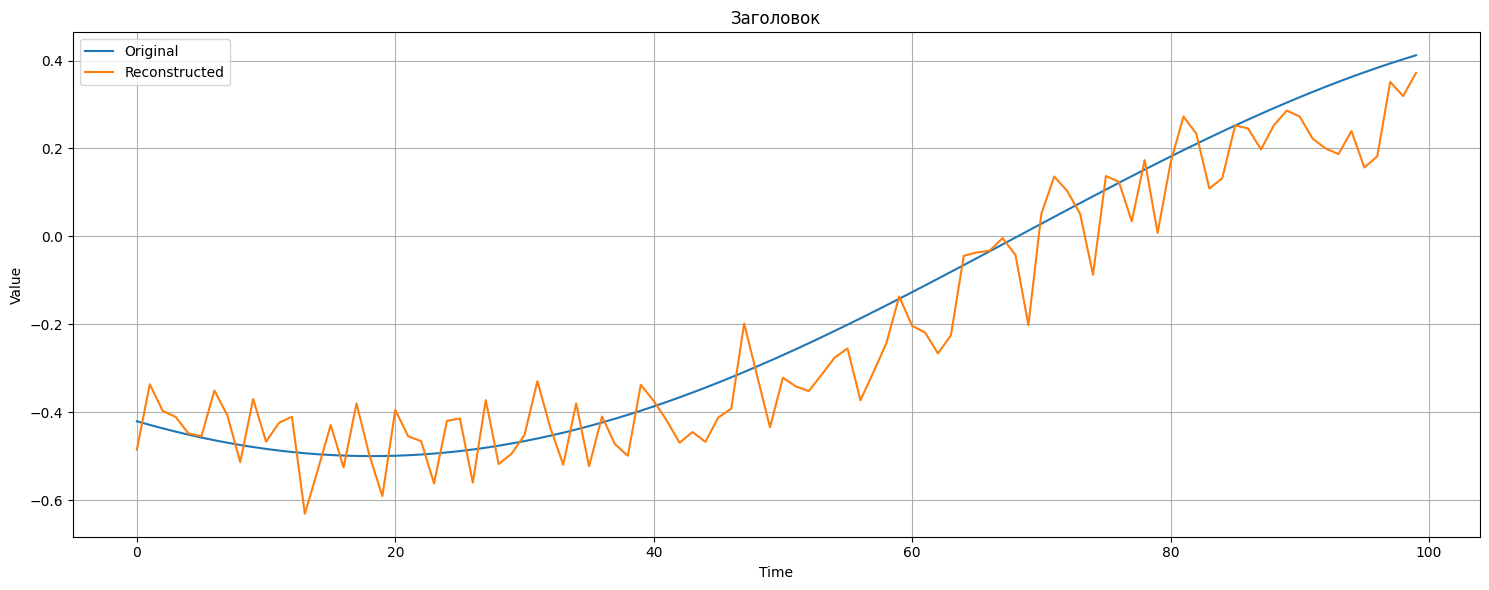

Model loaded from models/best_seasonal_base_128.pth


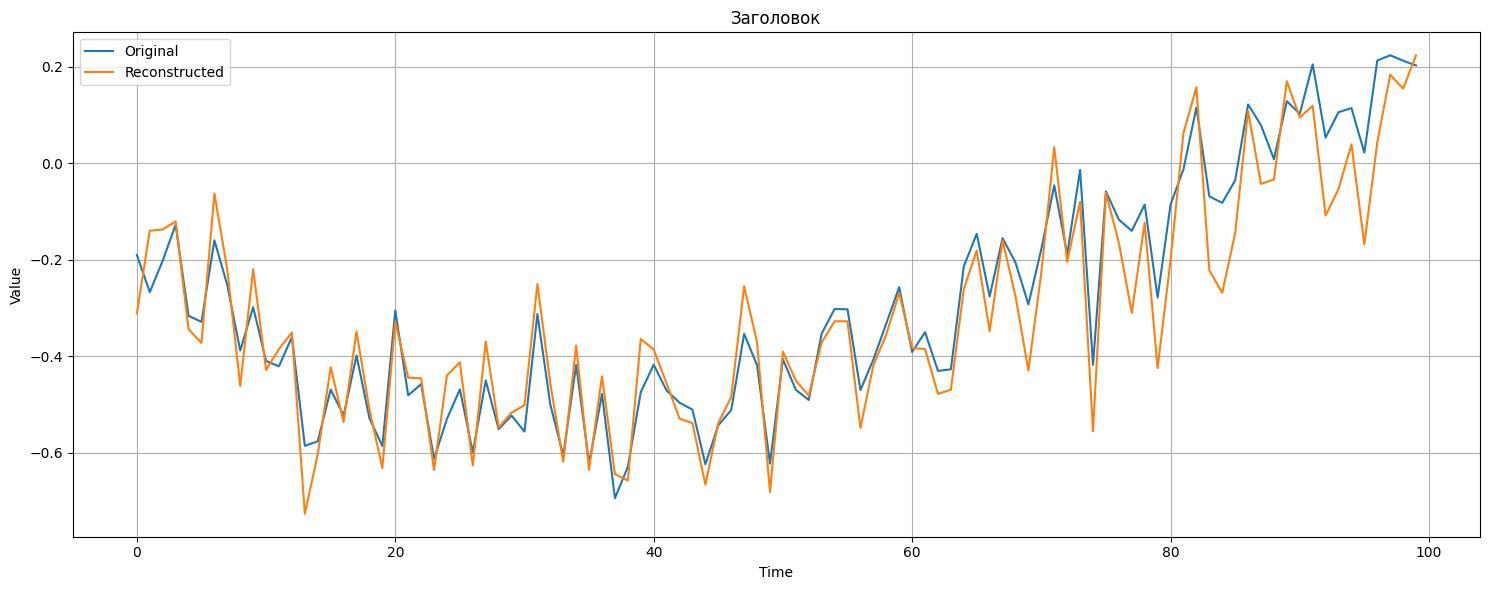

Model loaded from models/best_seasonal_base_128.pth


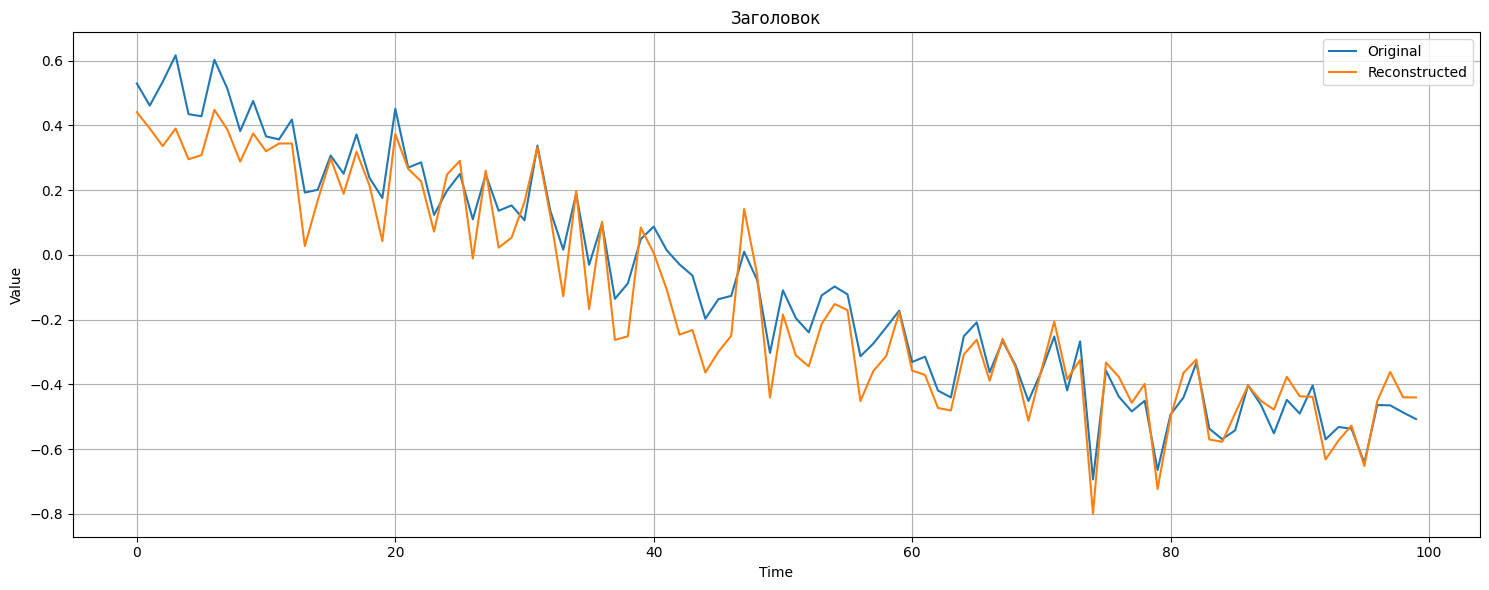

Model loaded from models/best_seasonal_base_128.pth


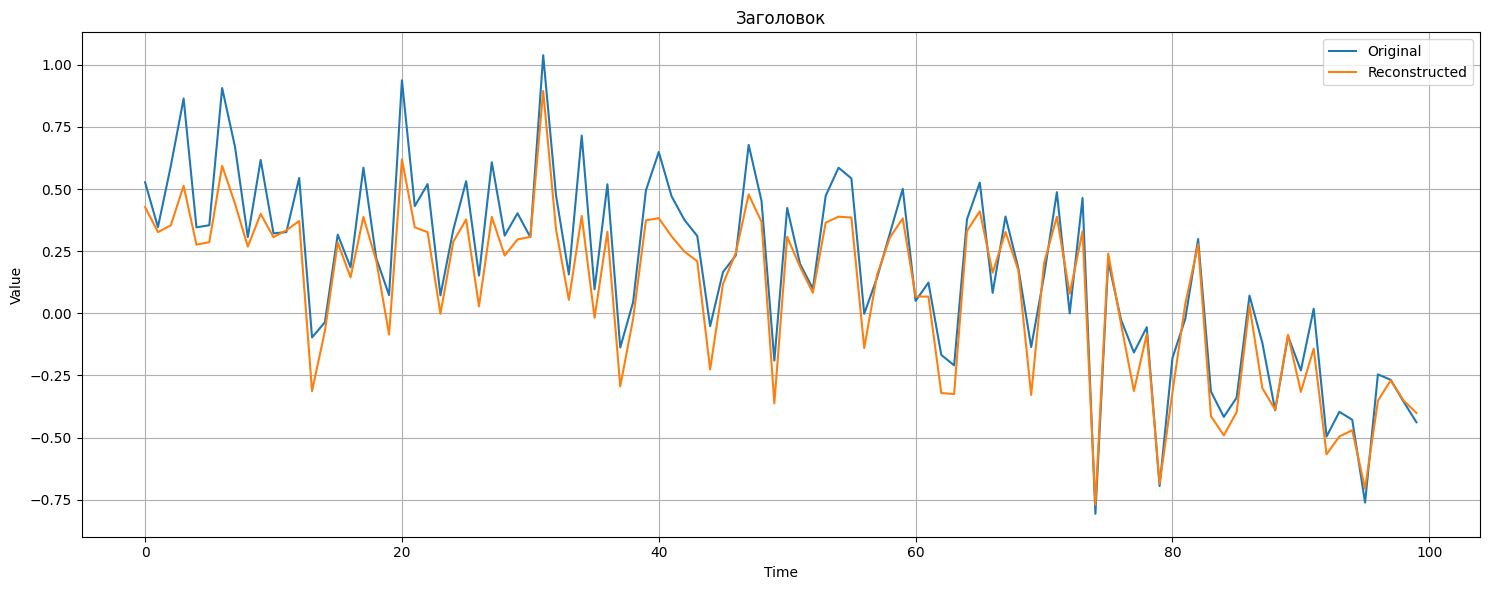

Model loaded from models/best_seasonal_base_128.pth


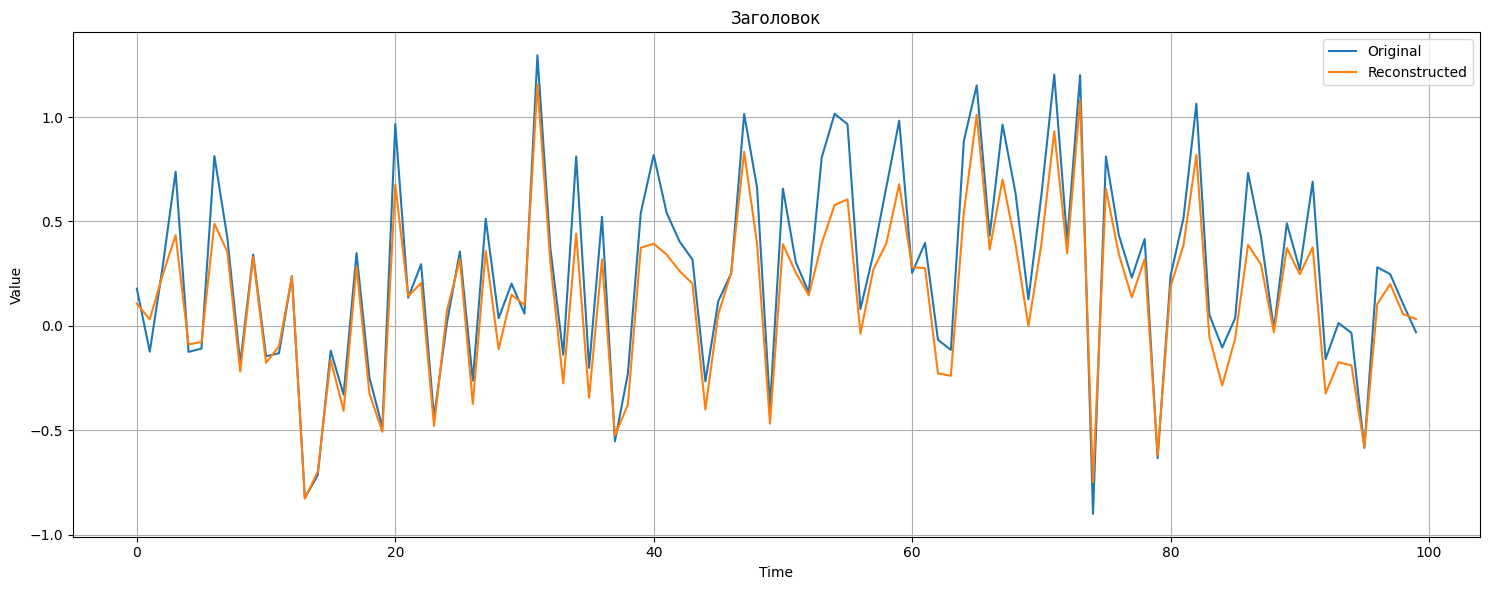

Model loaded from models/best_seasonal_base_128.pth


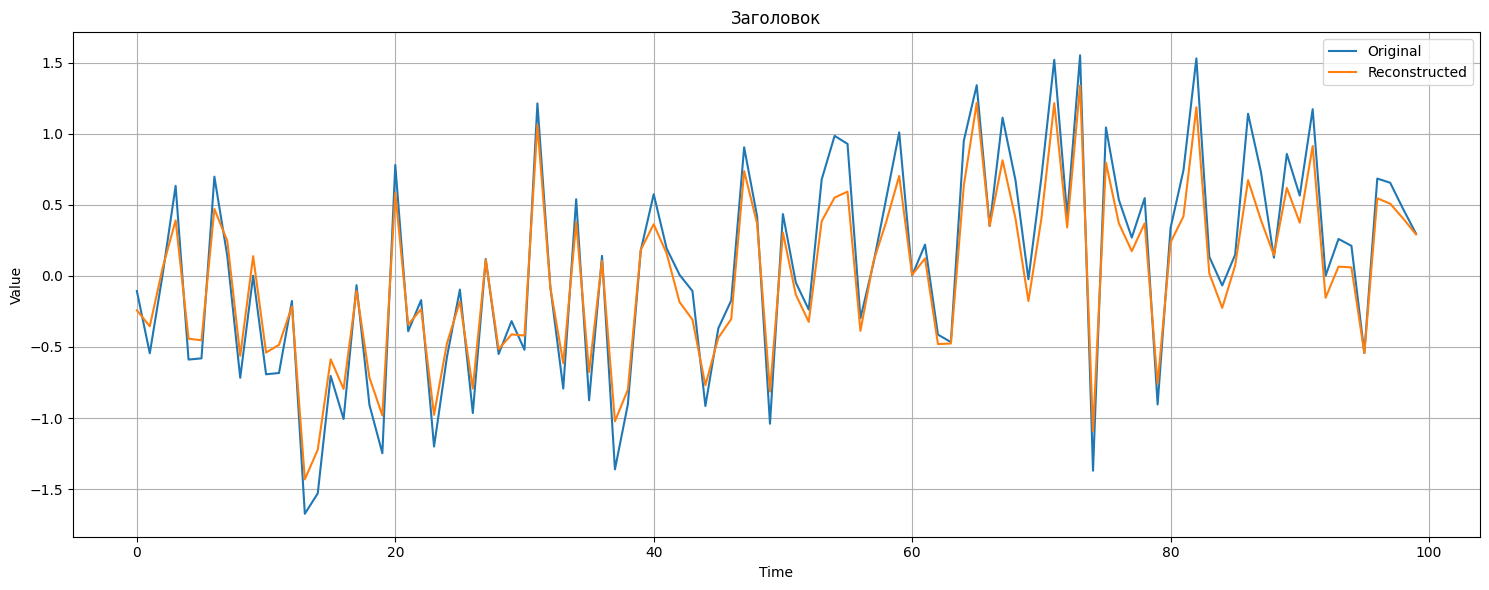

Model loaded from models/best_seasonal_base_128.pth


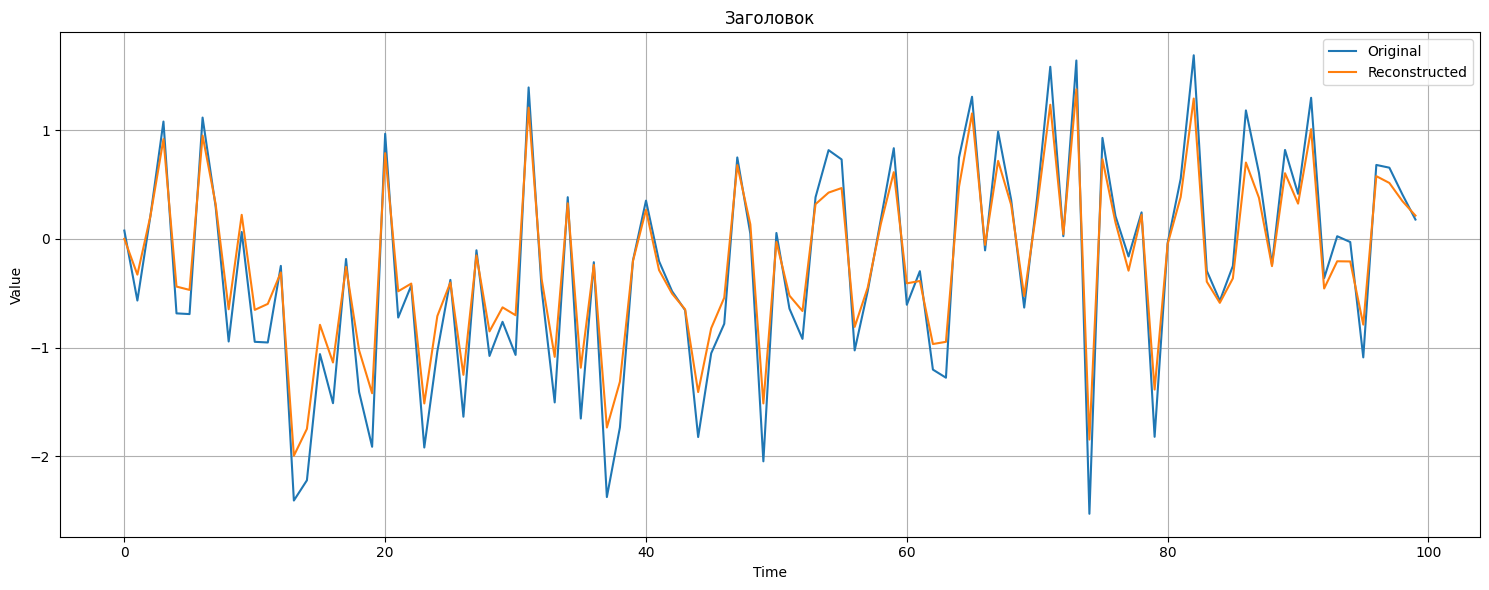

Model loaded from models/best_seasonal_base_128.pth


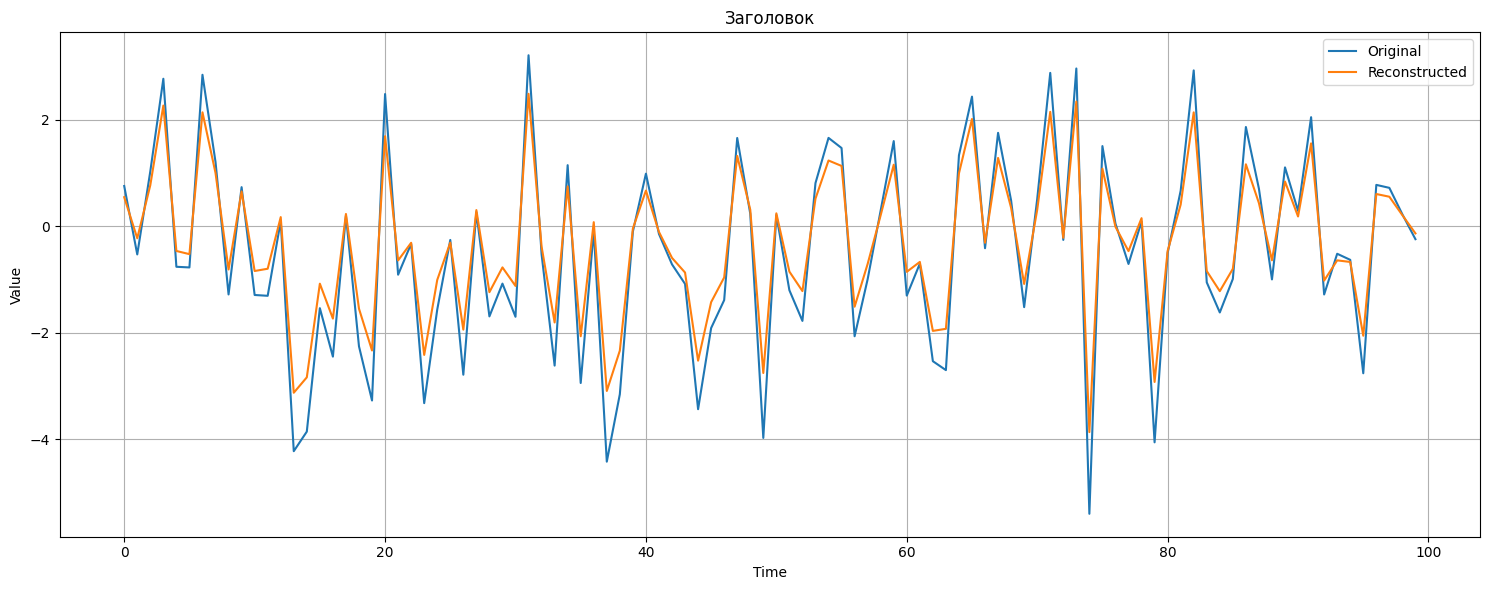

Model loaded from models/best_seasonal_base_128.pth


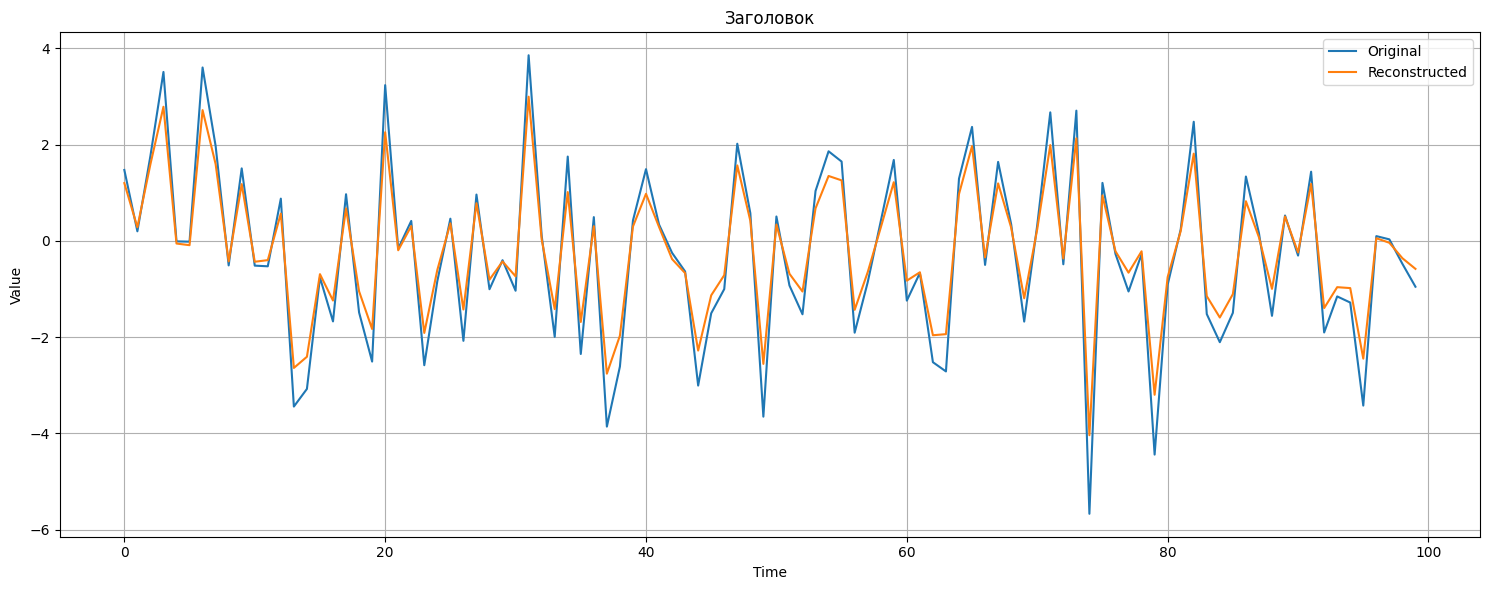

Model loaded from models/best_seasonal_base_128.pth


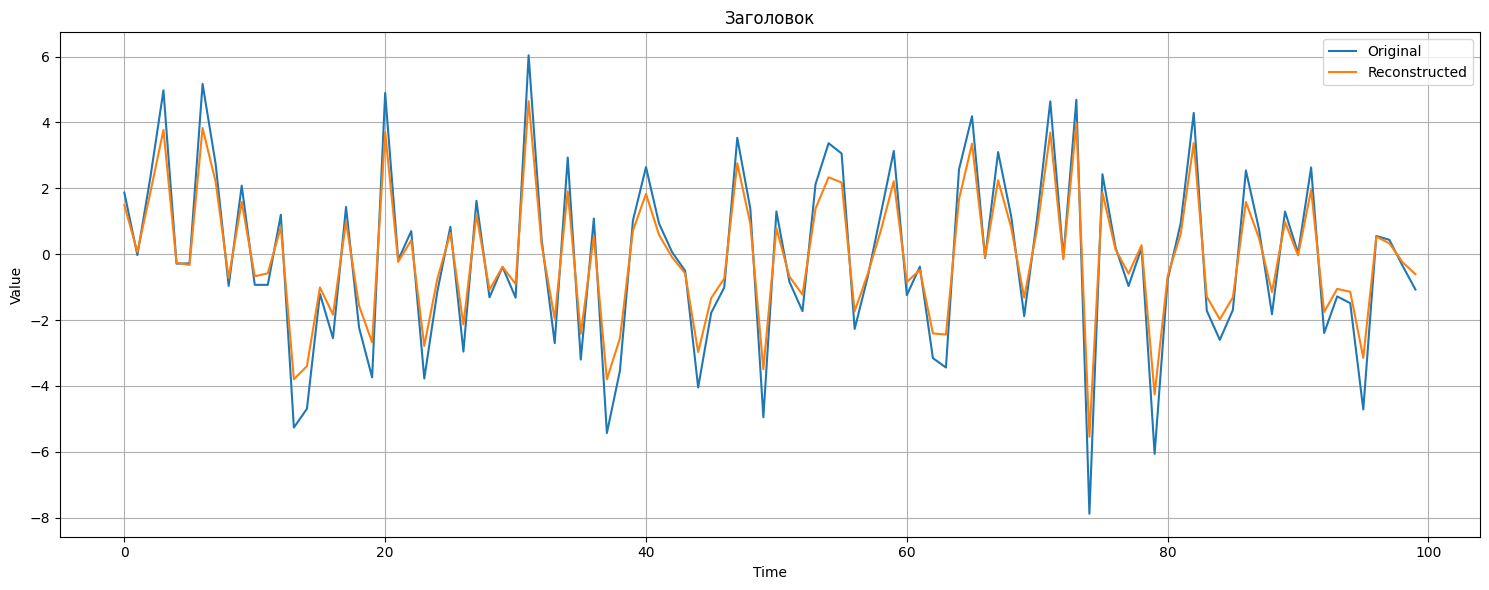

Model loaded from models/best_seasonal_base_128.pth


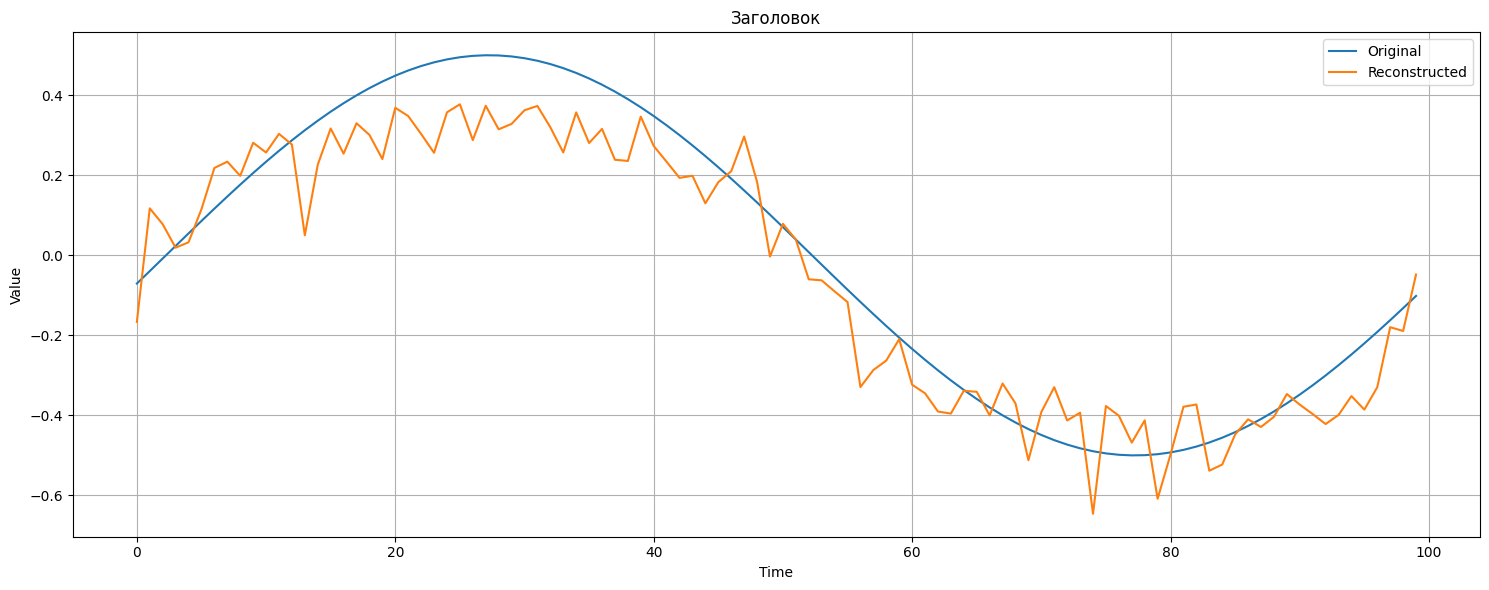

Model loaded from models/best_seasonal_base_128.pth


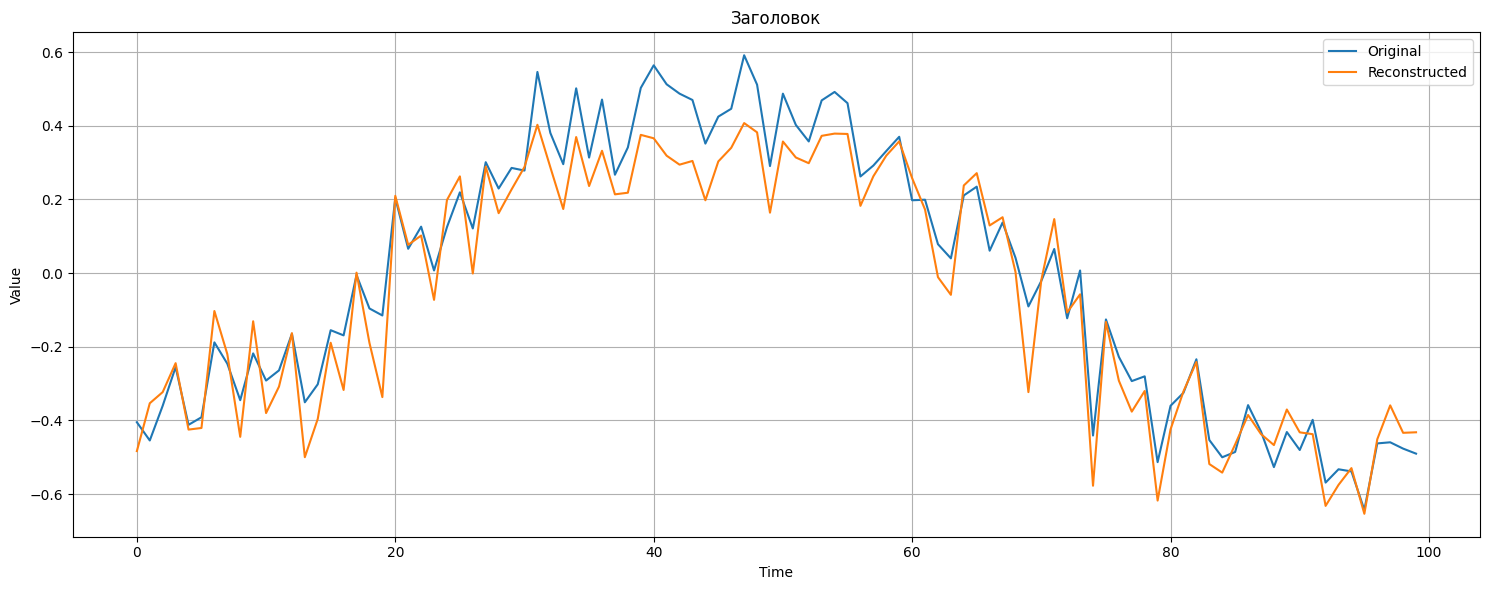

Model loaded from models/best_seasonal_base_128.pth


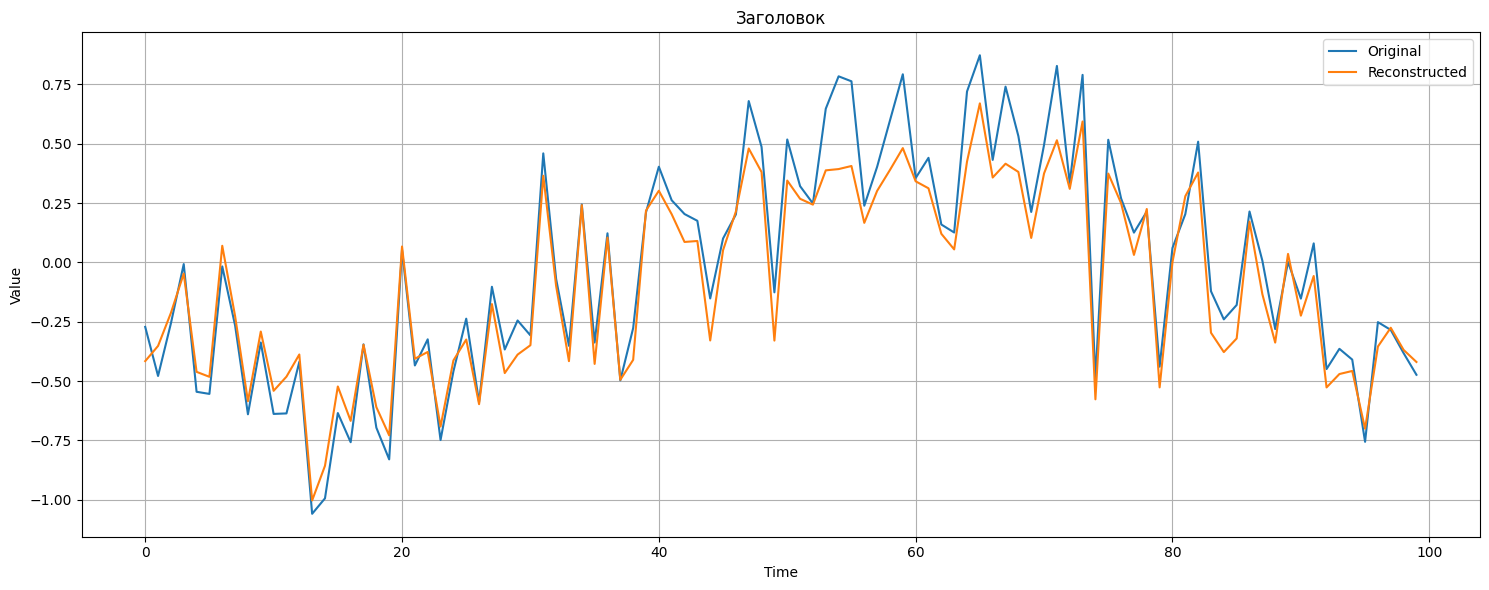

Model loaded from models/best_seasonal_base_128.pth


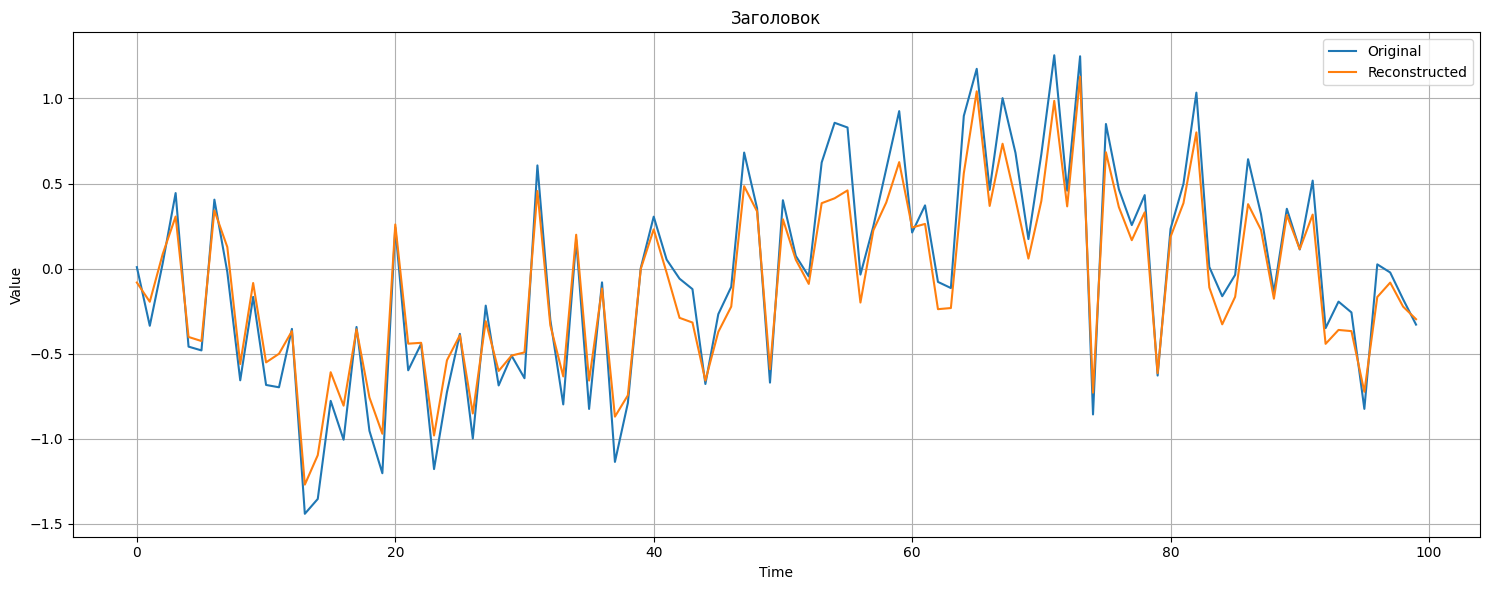

Model loaded from models/best_seasonal_base_128.pth


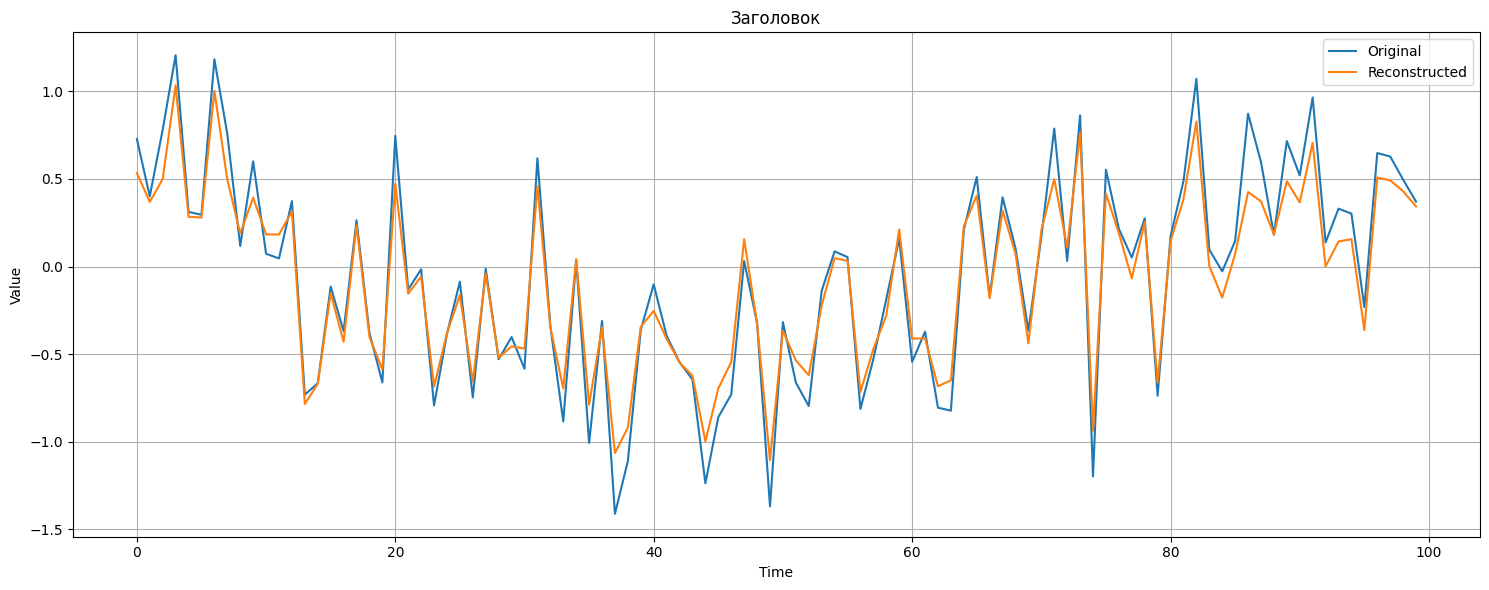

Model loaded from models/best_seasonal_base_128.pth


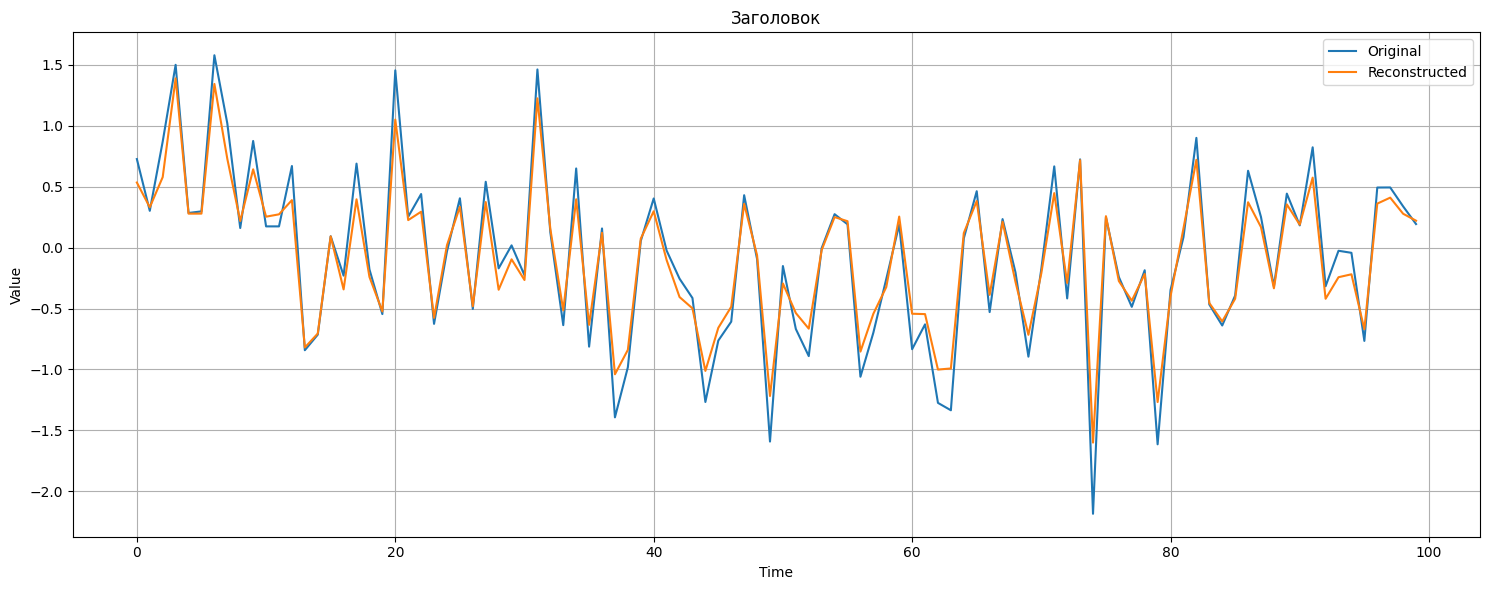

Model loaded from models/best_seasonal_base_128.pth


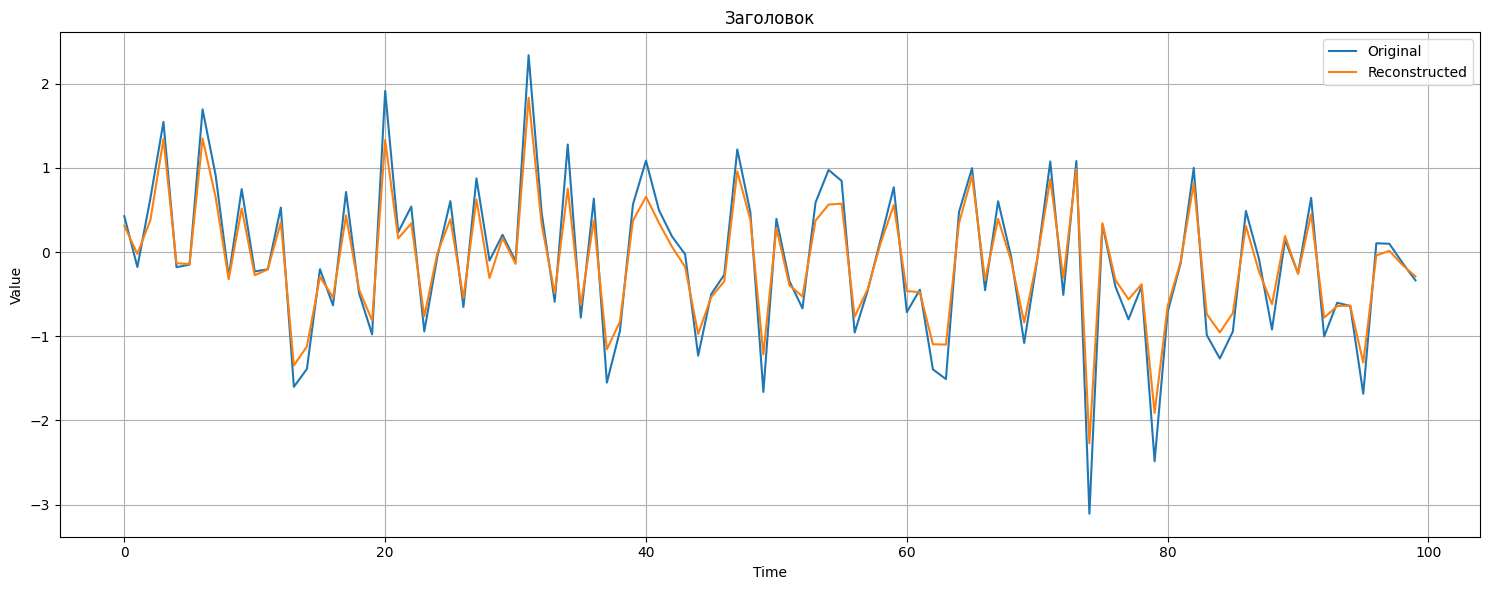

Model loaded from models/best_seasonal_base_128.pth


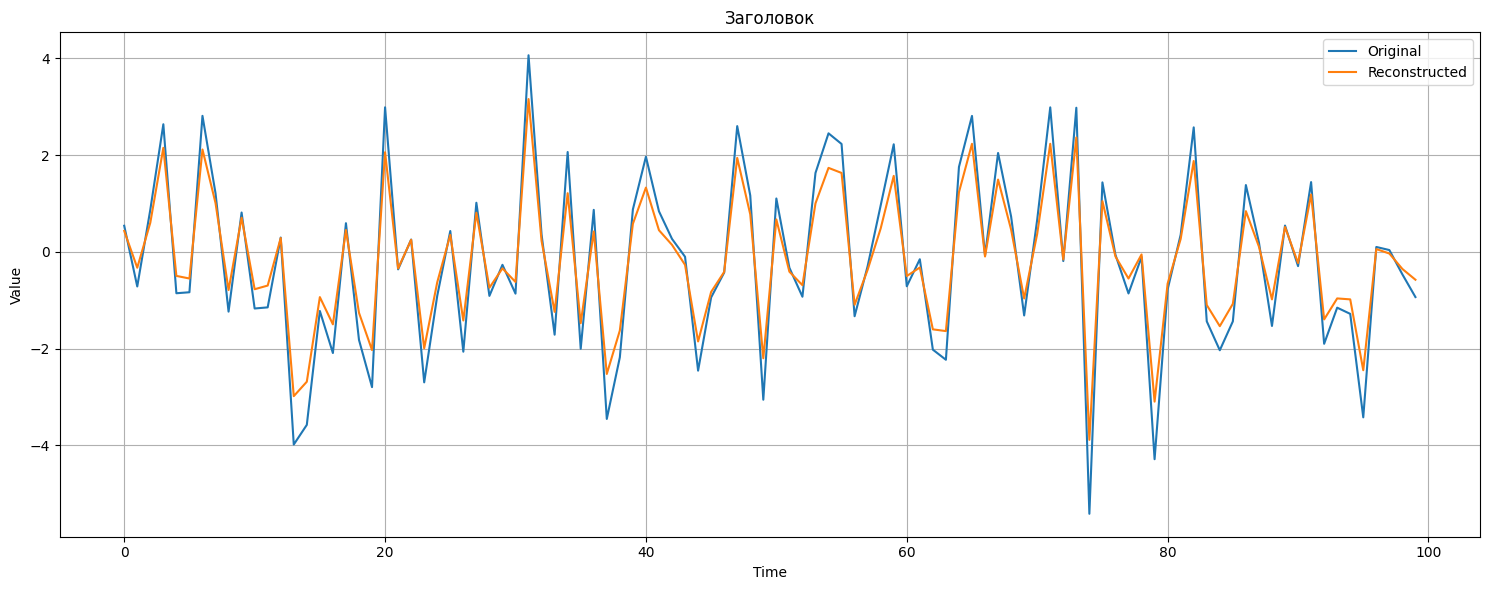

Model loaded from models/best_seasonal_base_128.pth


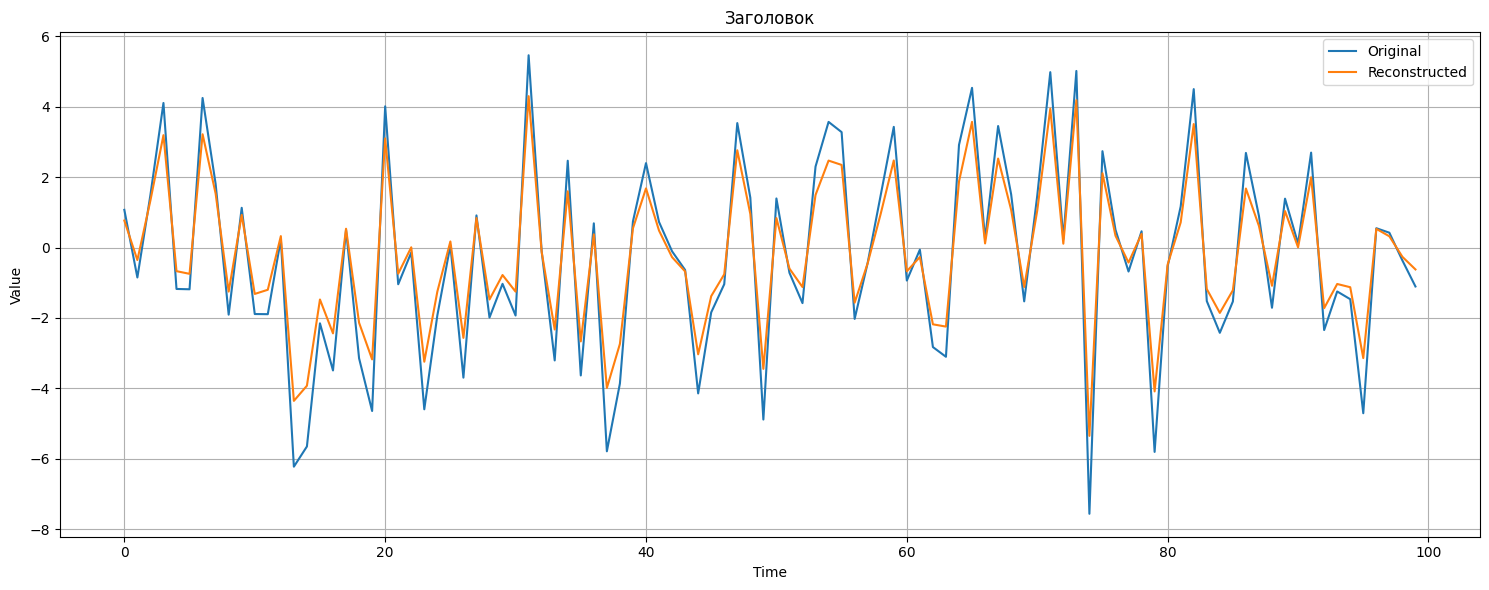

Model loaded from models/best_seasonal_base_128.pth


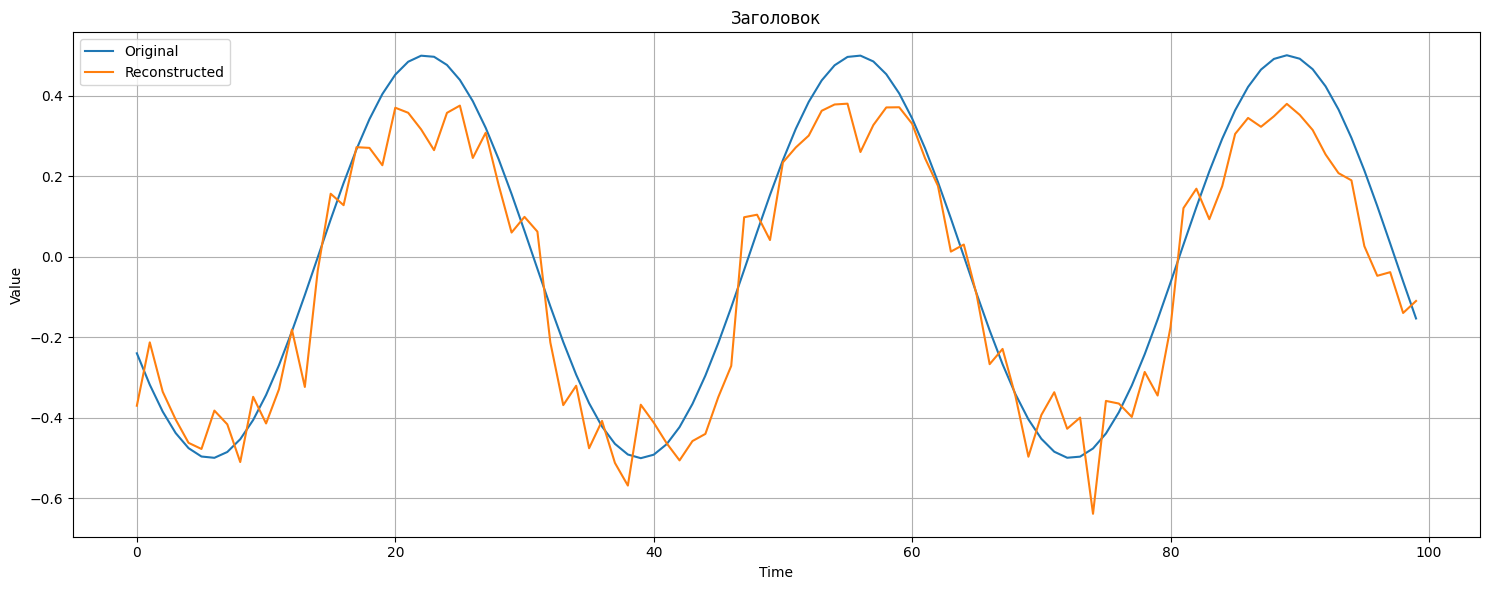

In [23]:
DATASET_NAME = 'data/seasonal_dataset.json'
# DATASET_NAME = 'data/seasonal_dataset1.json'
# DATASET_NAME = 'data/seasonal_dataset2.json'
MODEL_NAME = 'best_seasonal_base_128.pth'
# MODEL_NAME = 'best_seasonal_base1_128.pth'
# MODEL_NAME = 'best_seasonal_base2.pth'

# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path=DATASET_NAME,
    normalize=False
)

for t in range(1,100, 5):
    
    trained_model = load_model(LSTM_Autoencoder, model_args, 'models/', MODEL_NAME).to(device) 
    
    # Тестирование на примере
    test_sample, _ = dataset[t]
    test_sample = test_sample.unsqueeze(0).unsqueeze(-1).to(device)  # [1, seq_len, 1]

    trained_model.eval()
    with torch.no_grad():
        reconstructed = trained_model(test_sample)

    test_sample = test_sample.cpu()
    reconstructed = reconstructed.cpu()

    # Визуализация
    plot_series(
        series_list=[
            test_sample.squeeze().numpy(),
            reconstructed.squeeze().numpy()
        ],
        labels=["Original", "Reconstructed"],
        ylabel="Value",
        xlabel="Time",
        figsize=(15, 6),
    )


Model loaded from models/seasonal_base1_128.pth


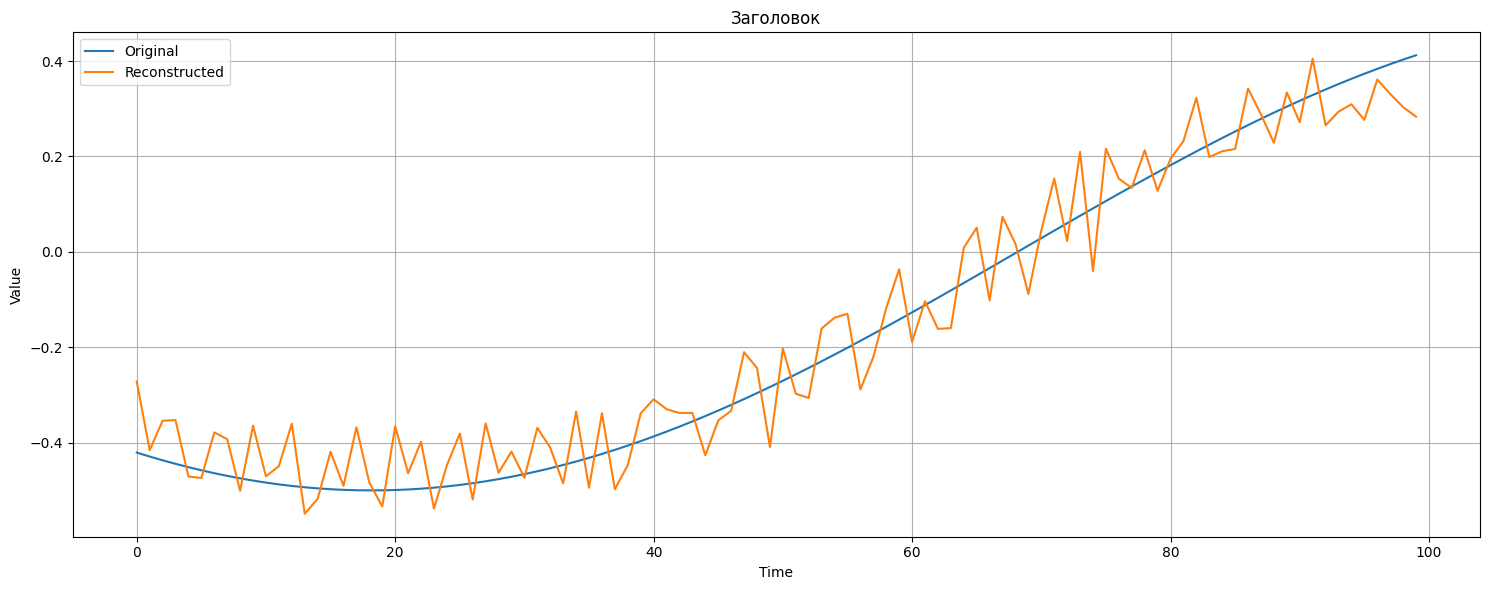

Model loaded from models/seasonal_base1_128.pth


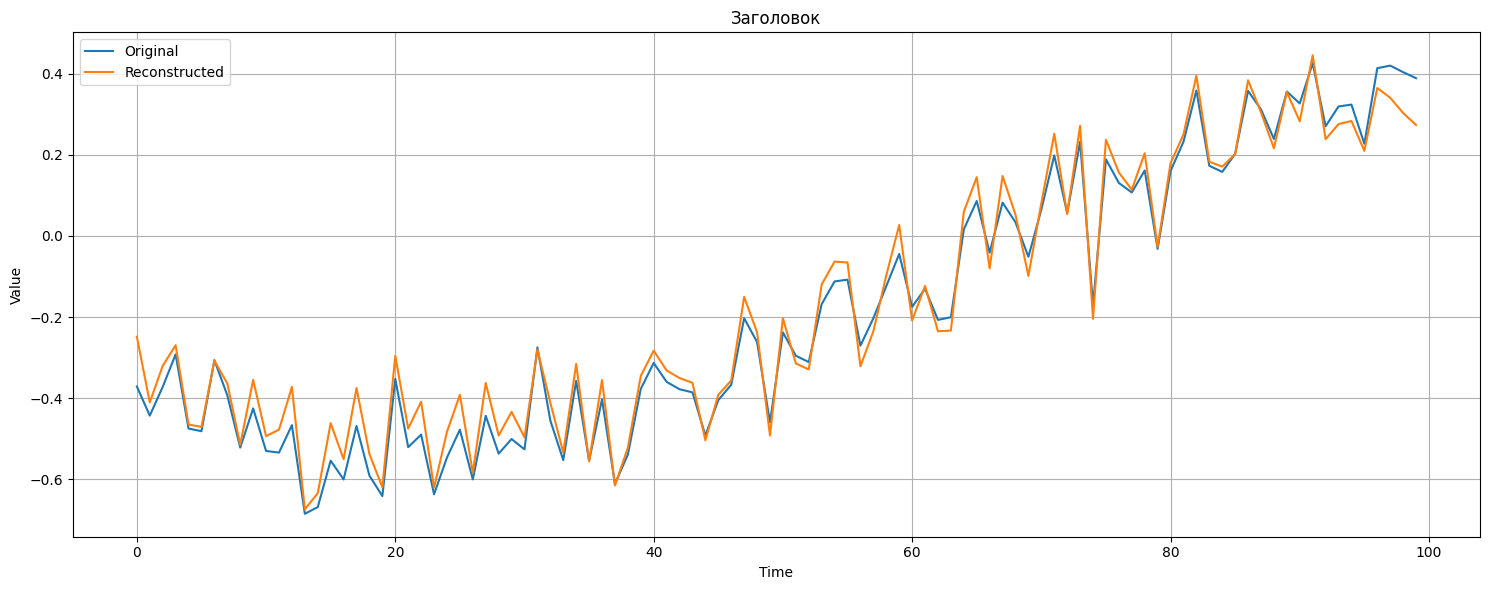

Model loaded from models/seasonal_base1_128.pth


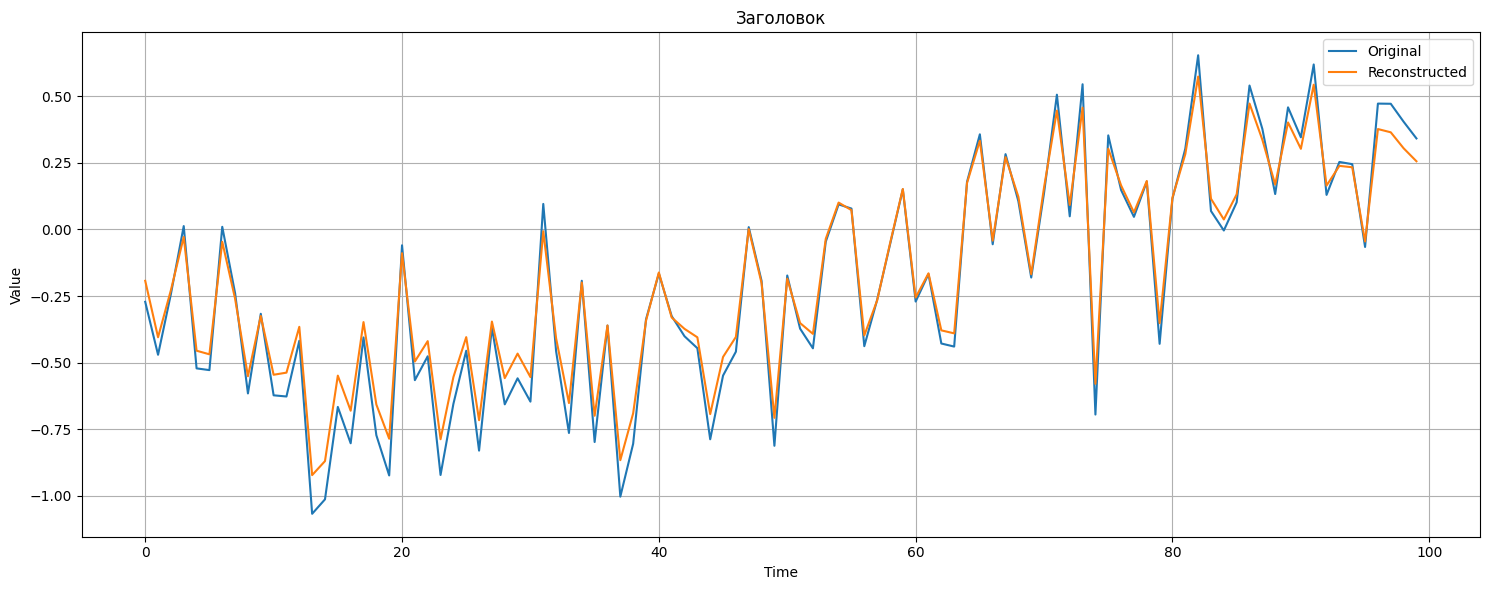

Model loaded from models/seasonal_base1_128.pth


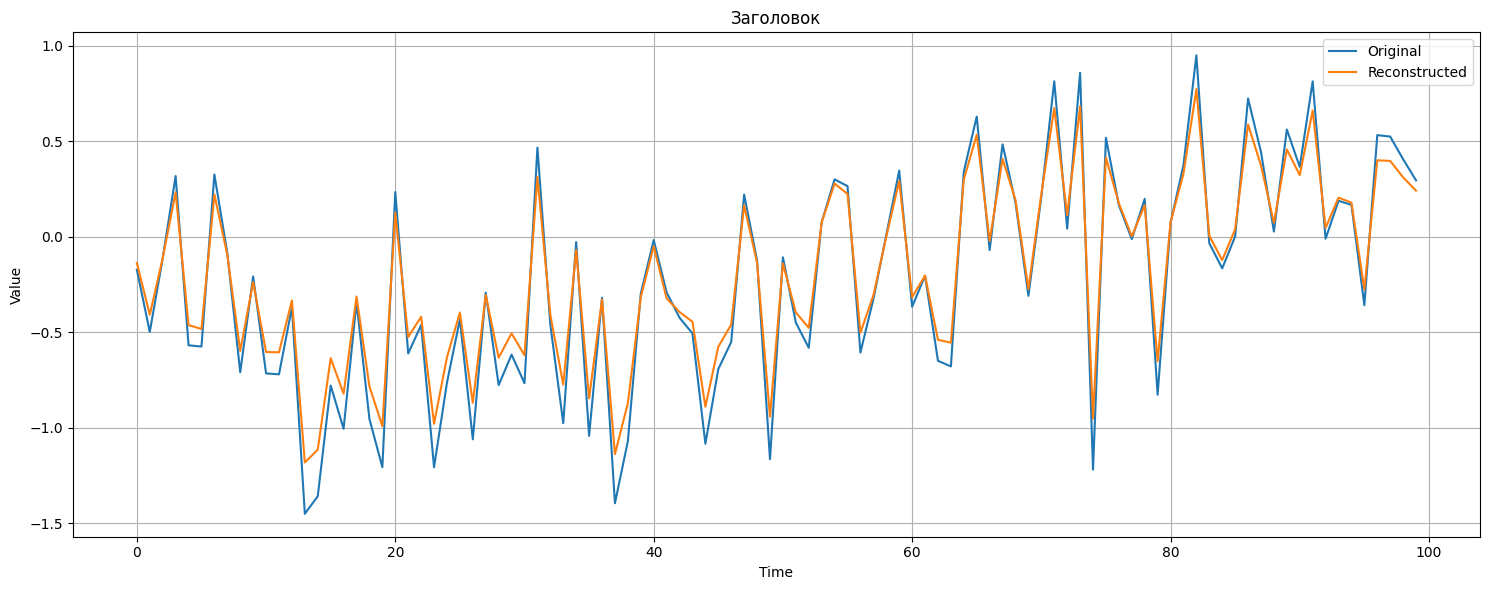

Model loaded from models/seasonal_base1_128.pth


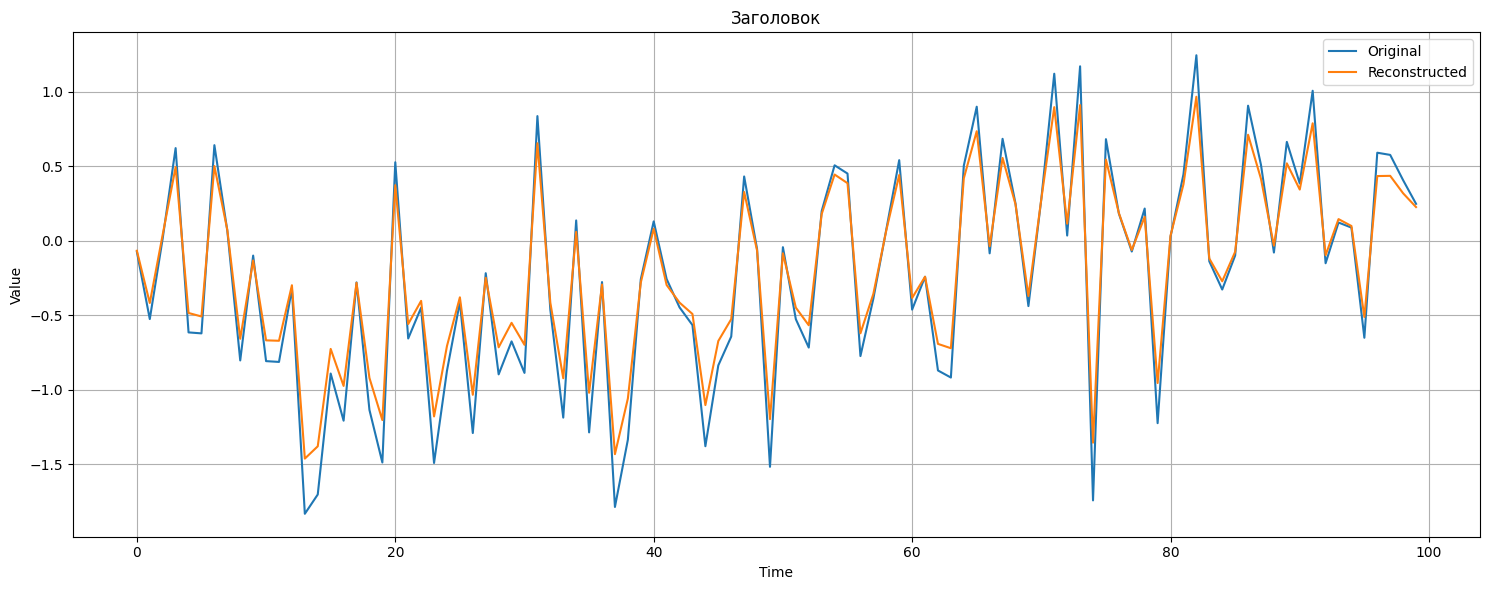

Model loaded from models/seasonal_base1_128.pth


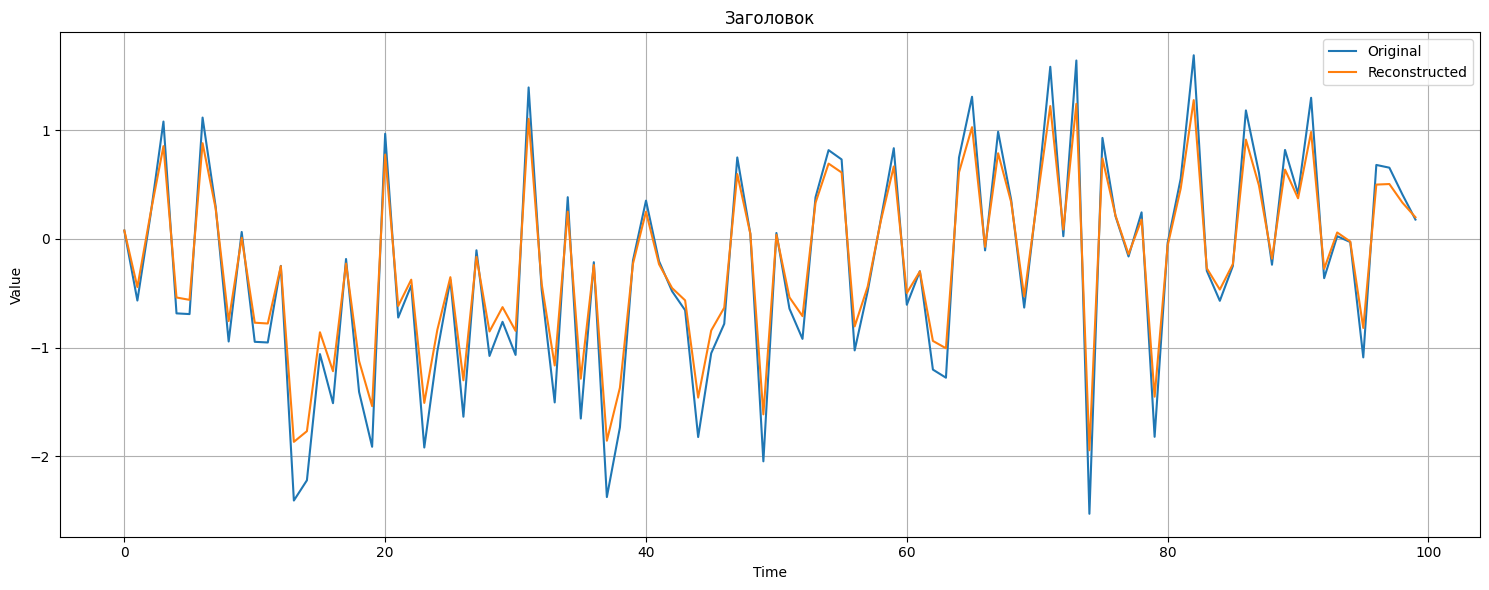

Model loaded from models/seasonal_base1_128.pth


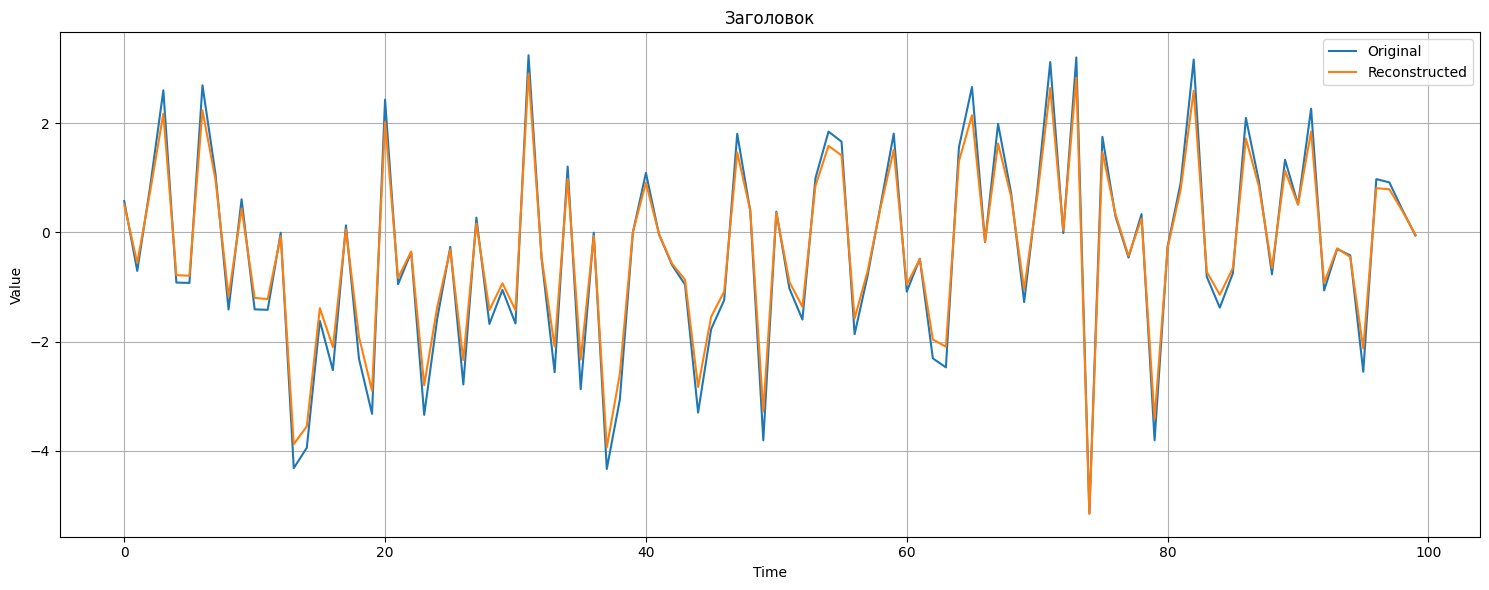

Model loaded from models/seasonal_base1_128.pth


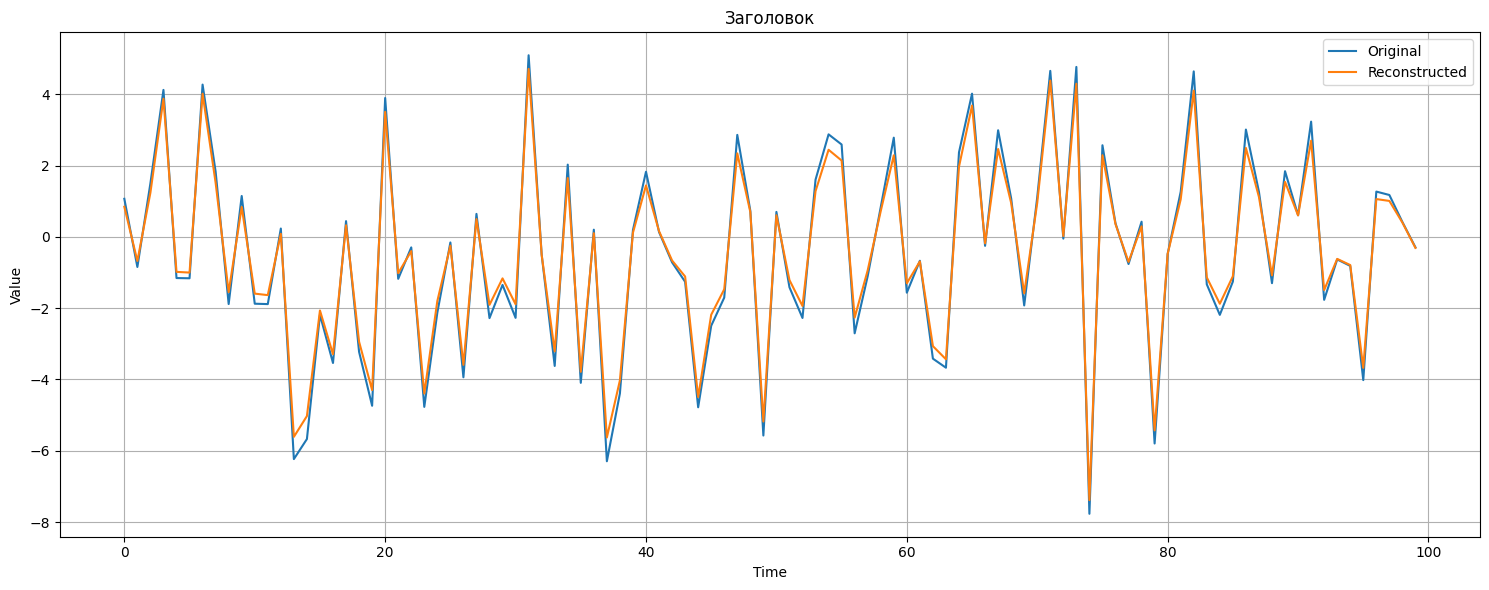

Model loaded from models/seasonal_base1_128.pth


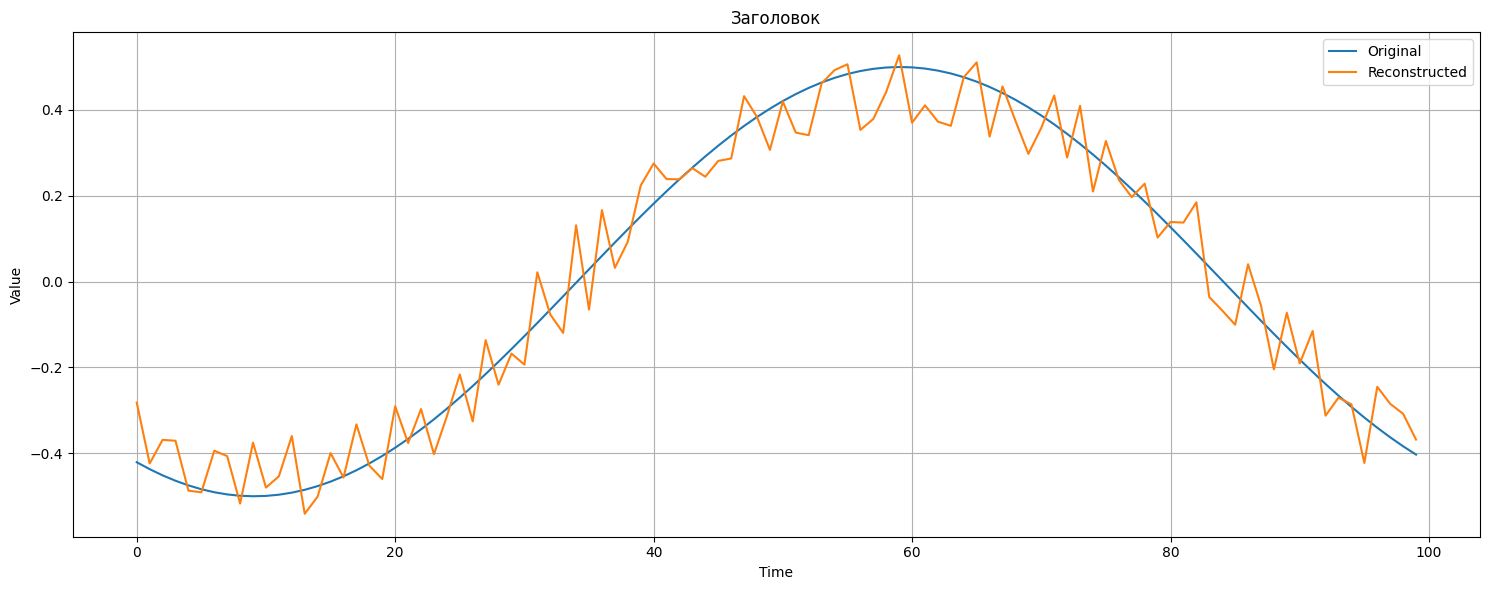

Model loaded from models/seasonal_base1_128.pth


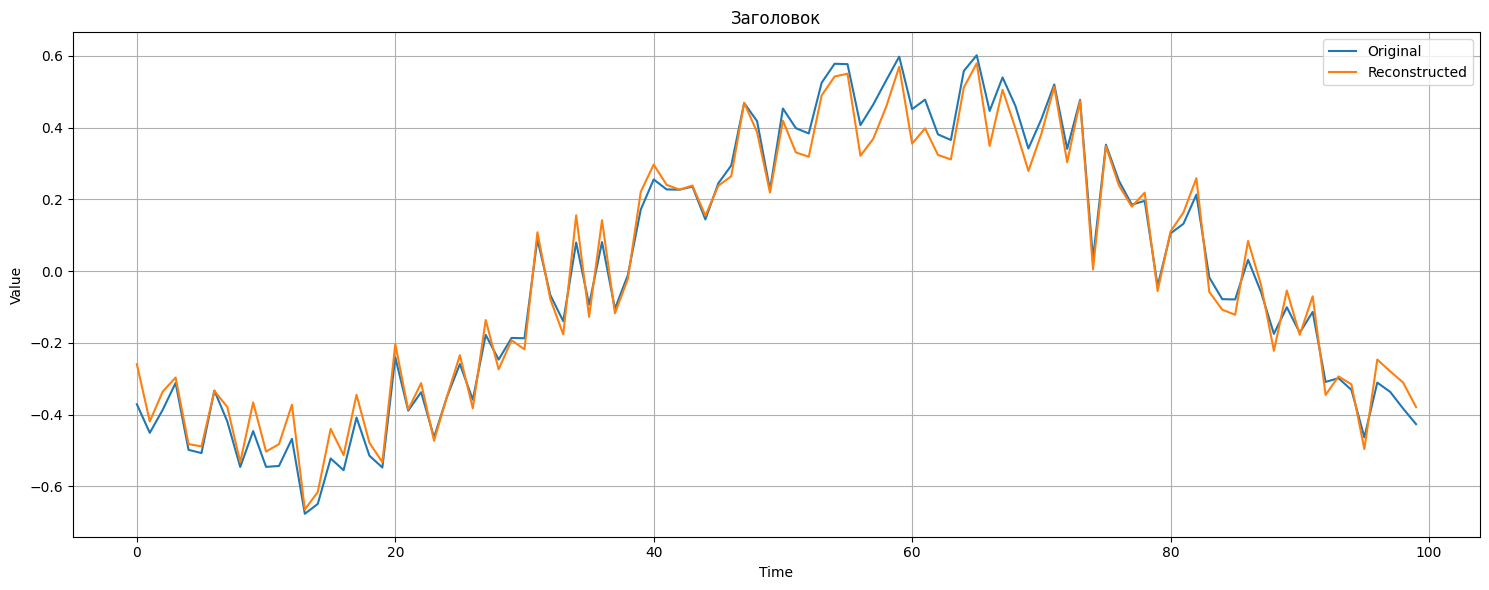

In [7]:
# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path='data/seasonal_dataset1.json',
    normalize=False
)

for t in range(1,20, 2):
    
    trained_model = load_model(LSTM_Autoencoder, model_args, 'models/', 'seasonal_base1_128.pth').to(device) 
    
    # Тестирование на примере
    test_sample, _ = dataset[t]
    test_sample = test_sample.unsqueeze(0).unsqueeze(-1).to(device)  # [1, seq_len, 1]

    trained_model.eval()
    with torch.no_grad():
        reconstructed = trained_model(test_sample)

    test_sample = test_sample.cpu()
    reconstructed = reconstructed.cpu()

    # Визуализация
    plot_series(
        series_list=[
            test_sample.squeeze().numpy(),
            reconstructed.squeeze().numpy()
        ],
        labels=["Original", "Reconstructed"],
        ylabel="Value",
        xlabel="Time",
        figsize=(15, 6),
    )


Model loaded from models/best_seasonal_base2_128.pth


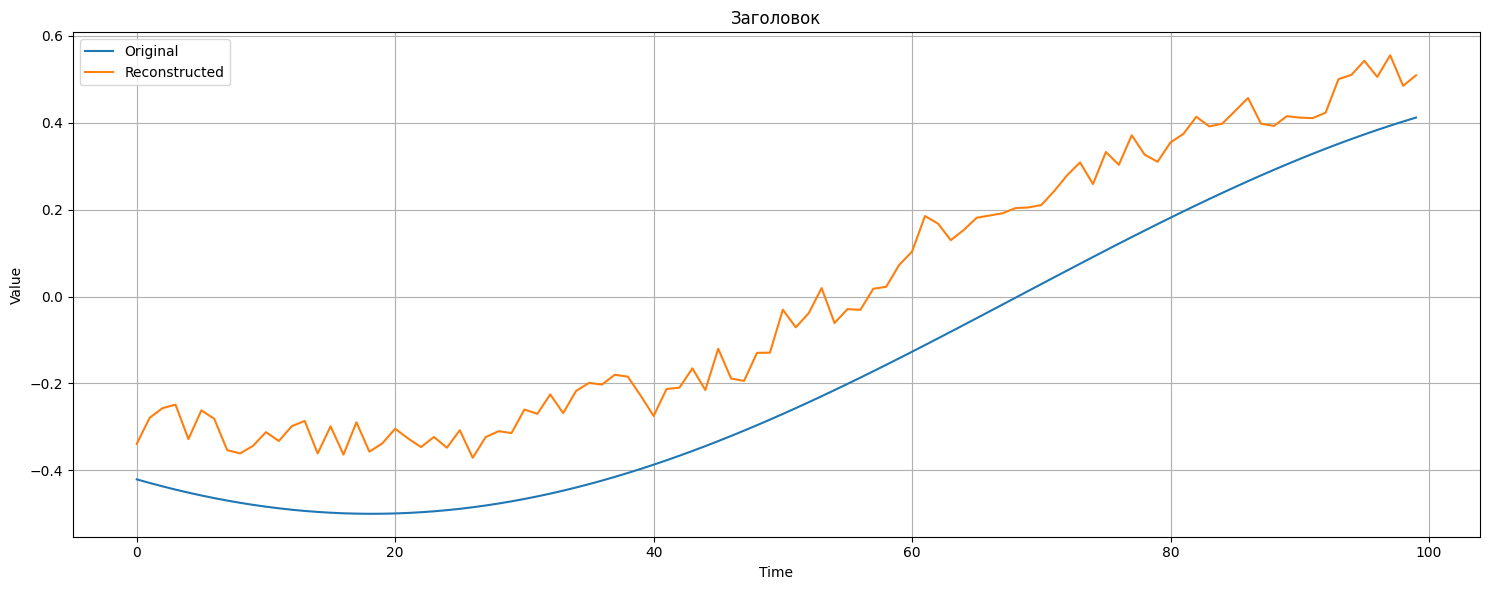

Model loaded from models/best_seasonal_base2_128.pth


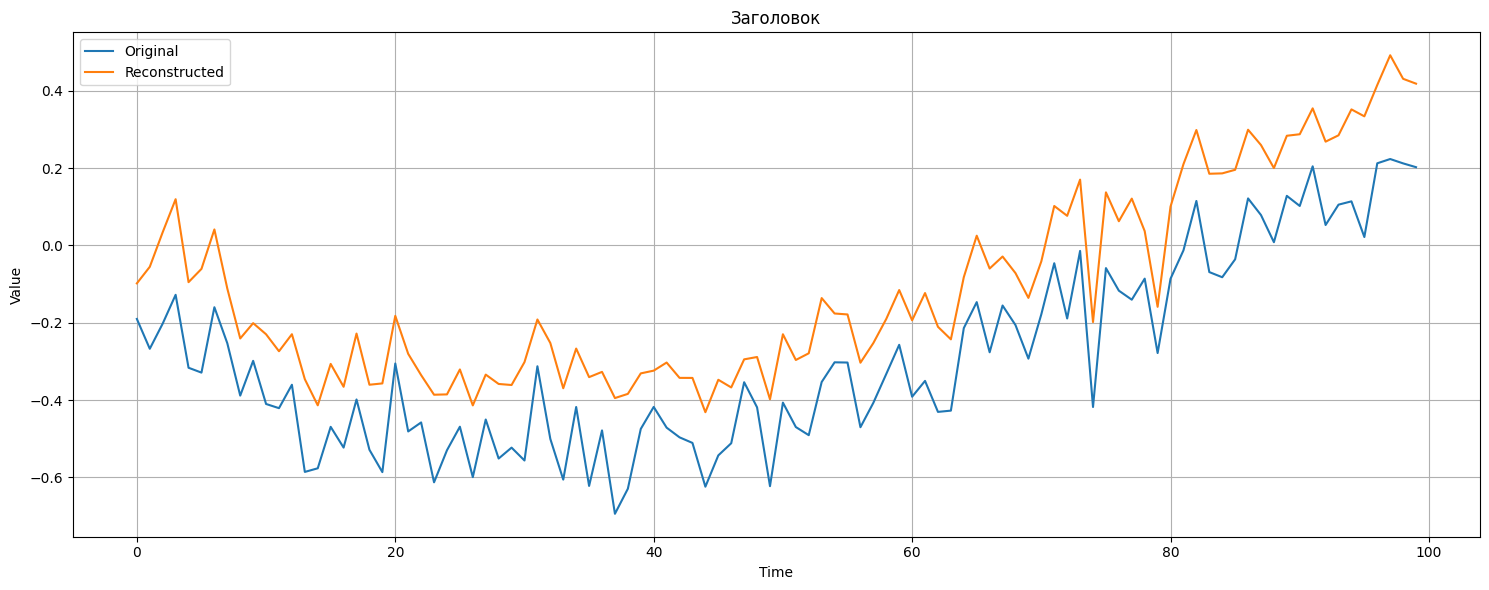

Model loaded from models/best_seasonal_base2_128.pth


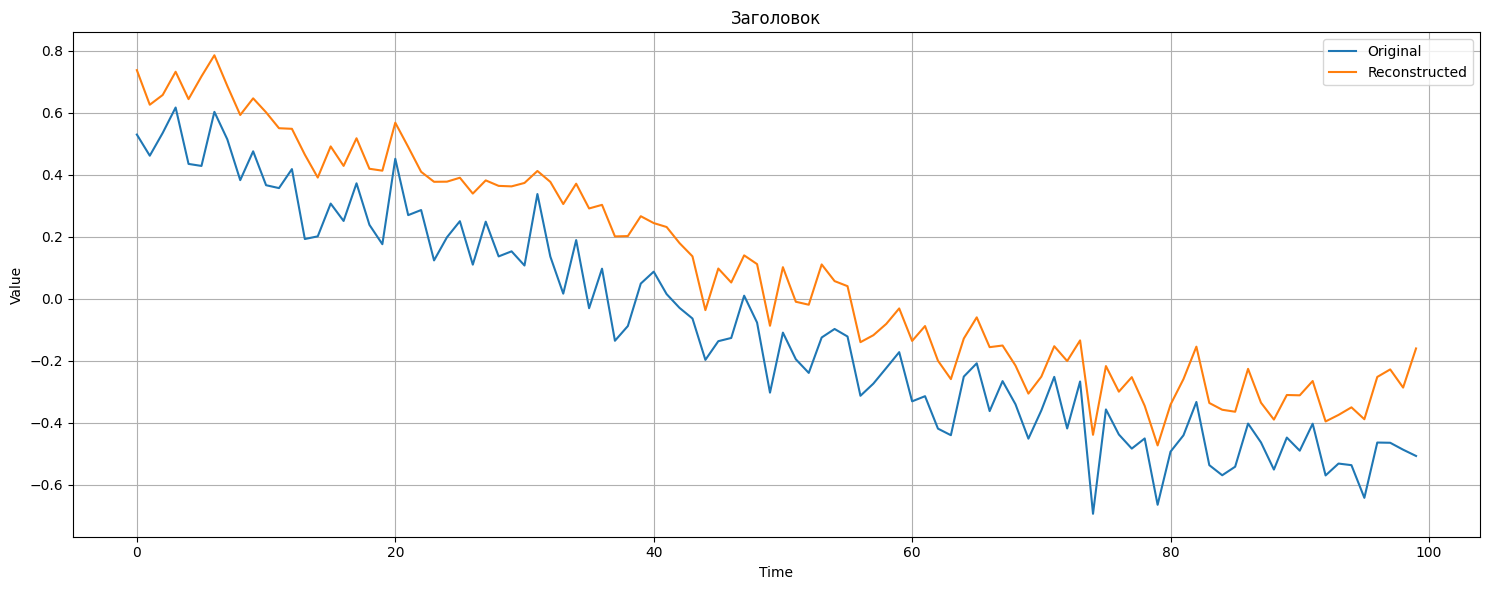

Model loaded from models/best_seasonal_base2_128.pth


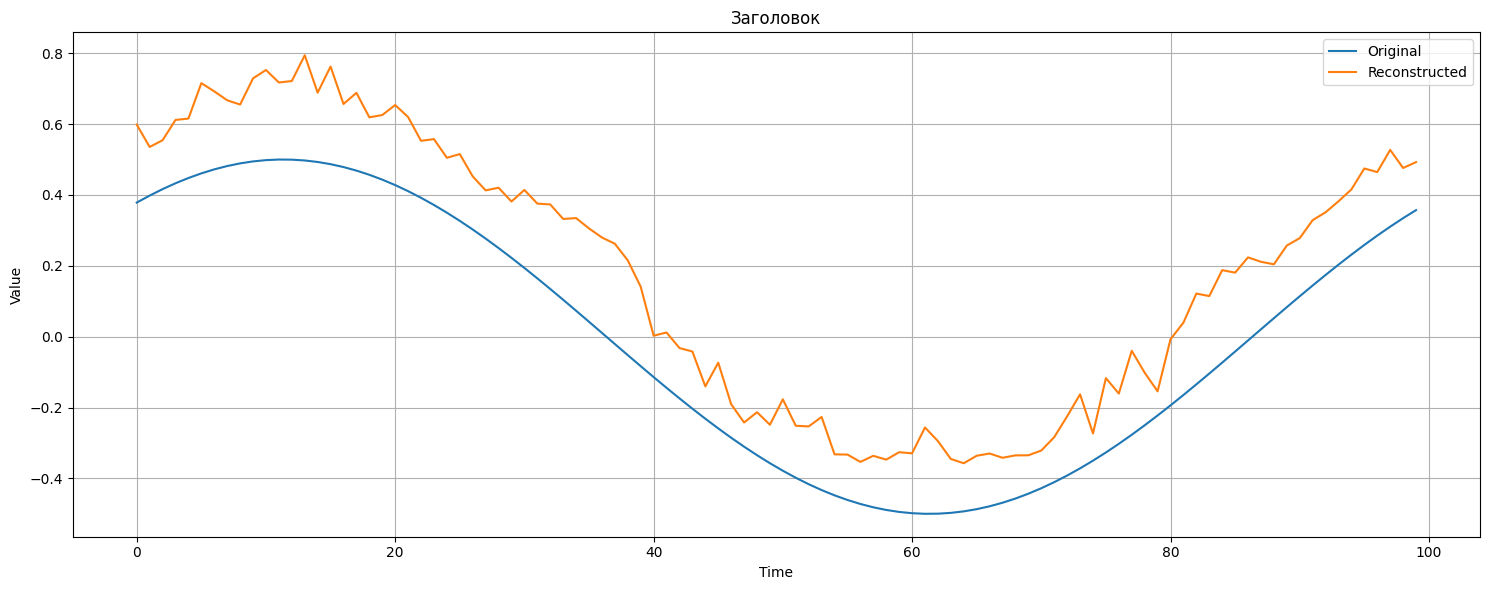

Model loaded from models/best_seasonal_base2_128.pth


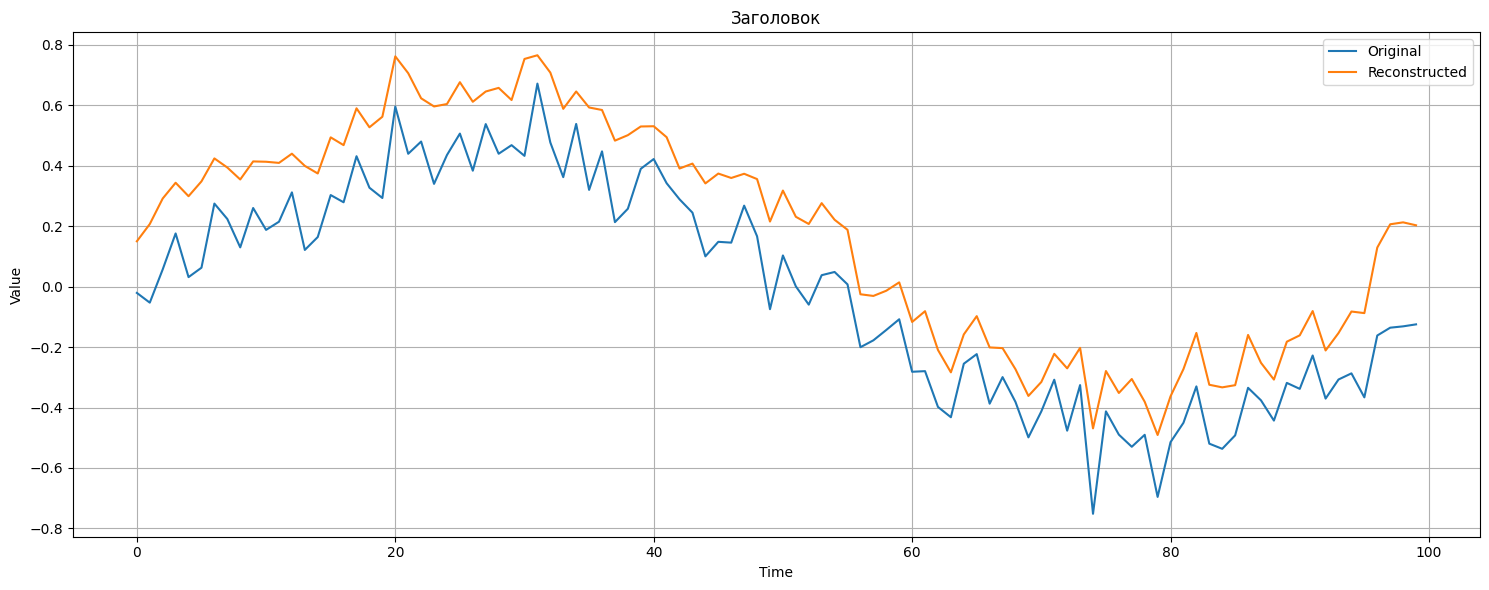

Model loaded from models/best_seasonal_base2_128.pth


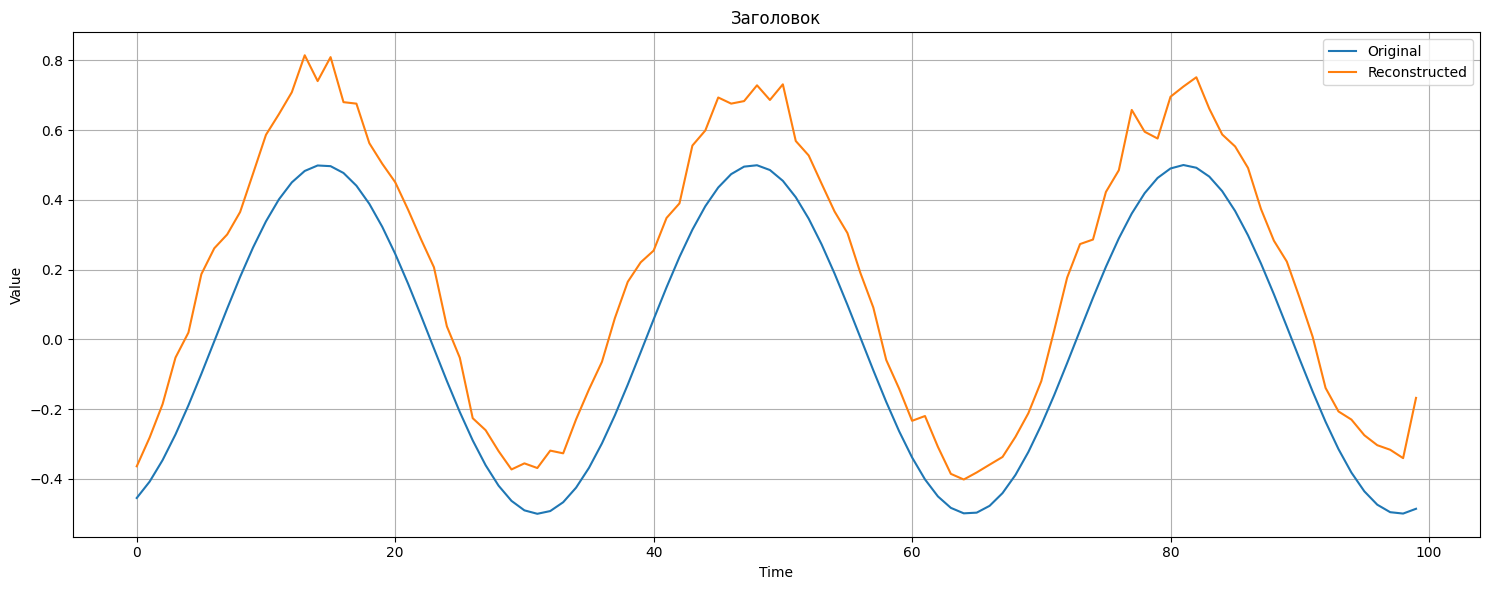

Model loaded from models/best_seasonal_base2_128.pth


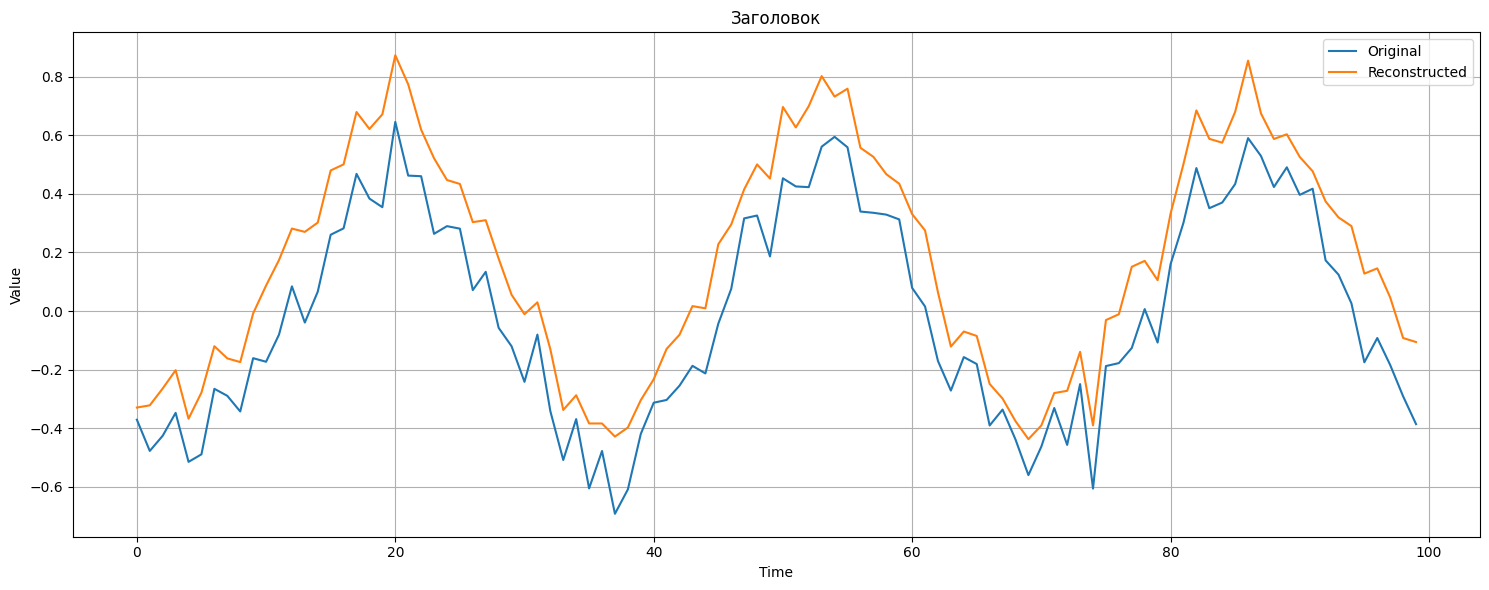

Model loaded from models/best_seasonal_base2_128.pth


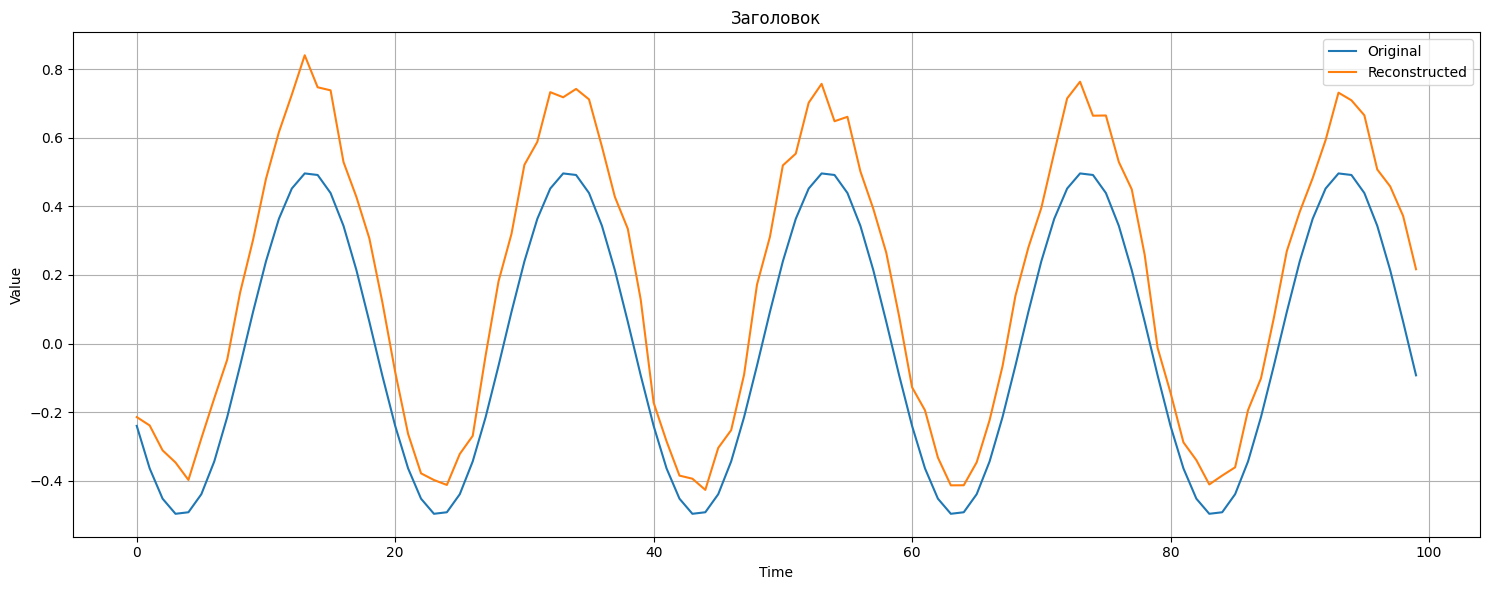

Model loaded from models/best_seasonal_base2_128.pth


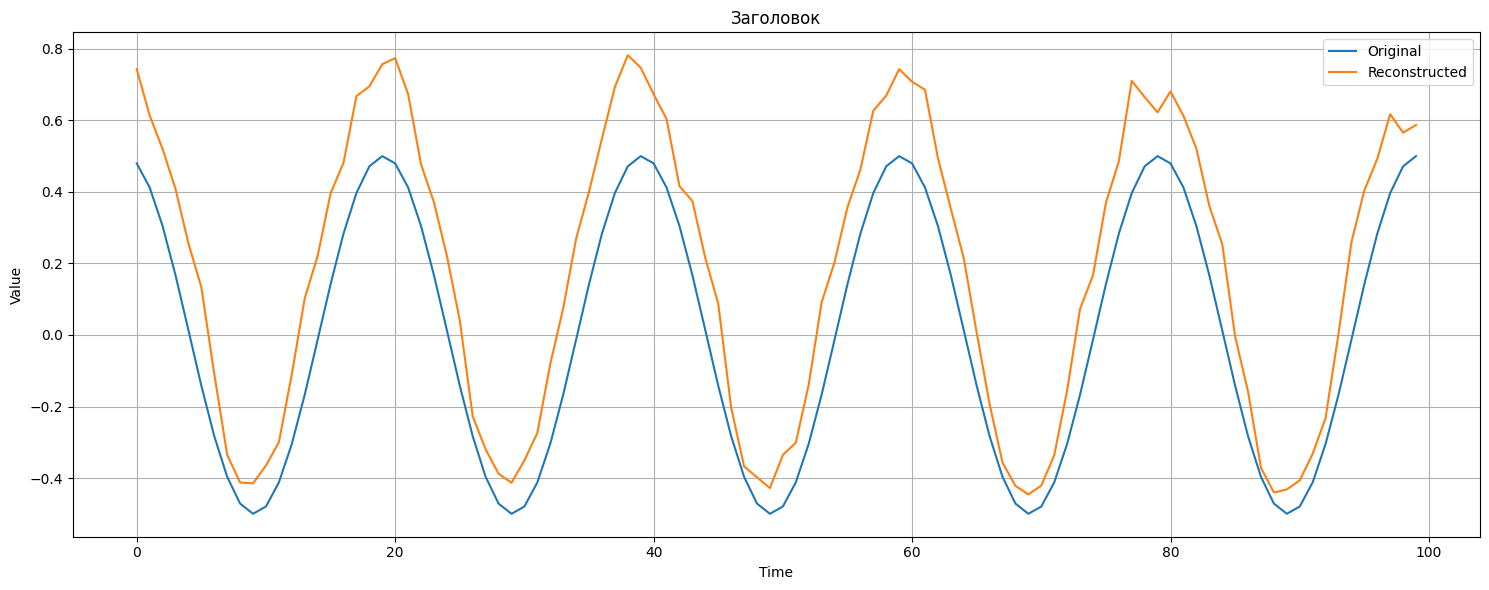

Model loaded from models/best_seasonal_base2_128.pth


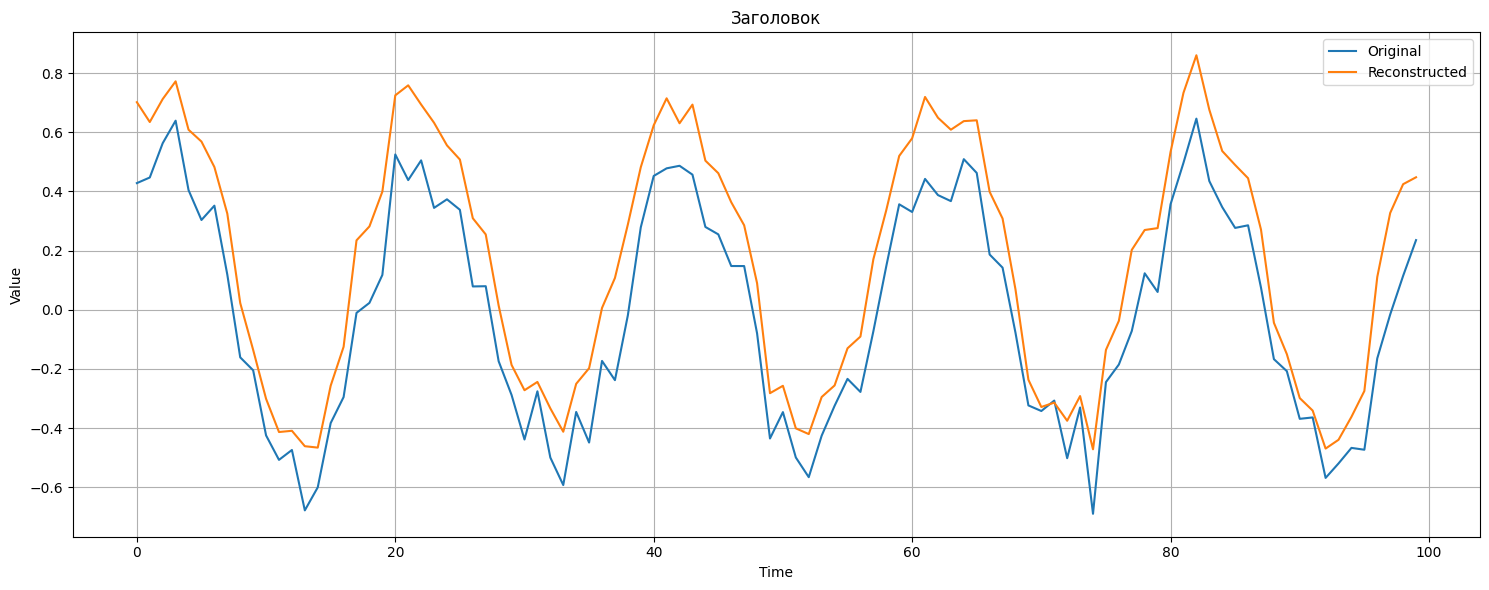

Model loaded from models/best_seasonal_base2_128.pth


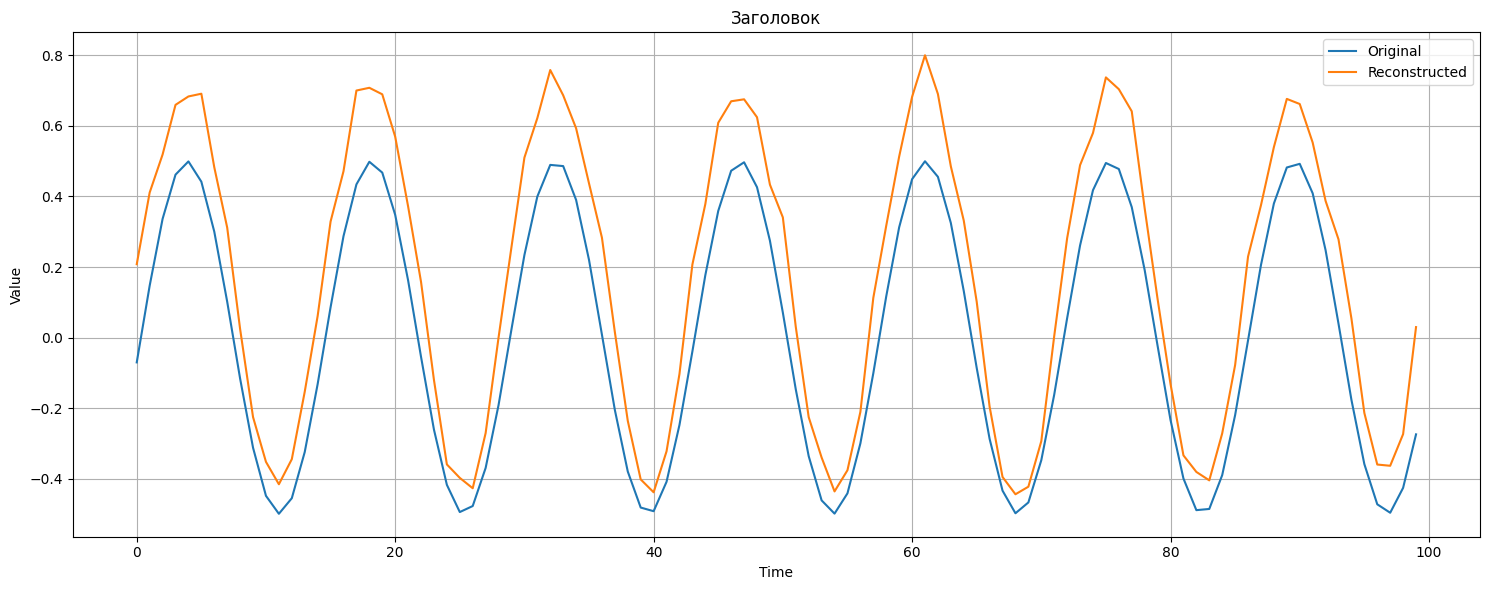

Model loaded from models/best_seasonal_base2_128.pth


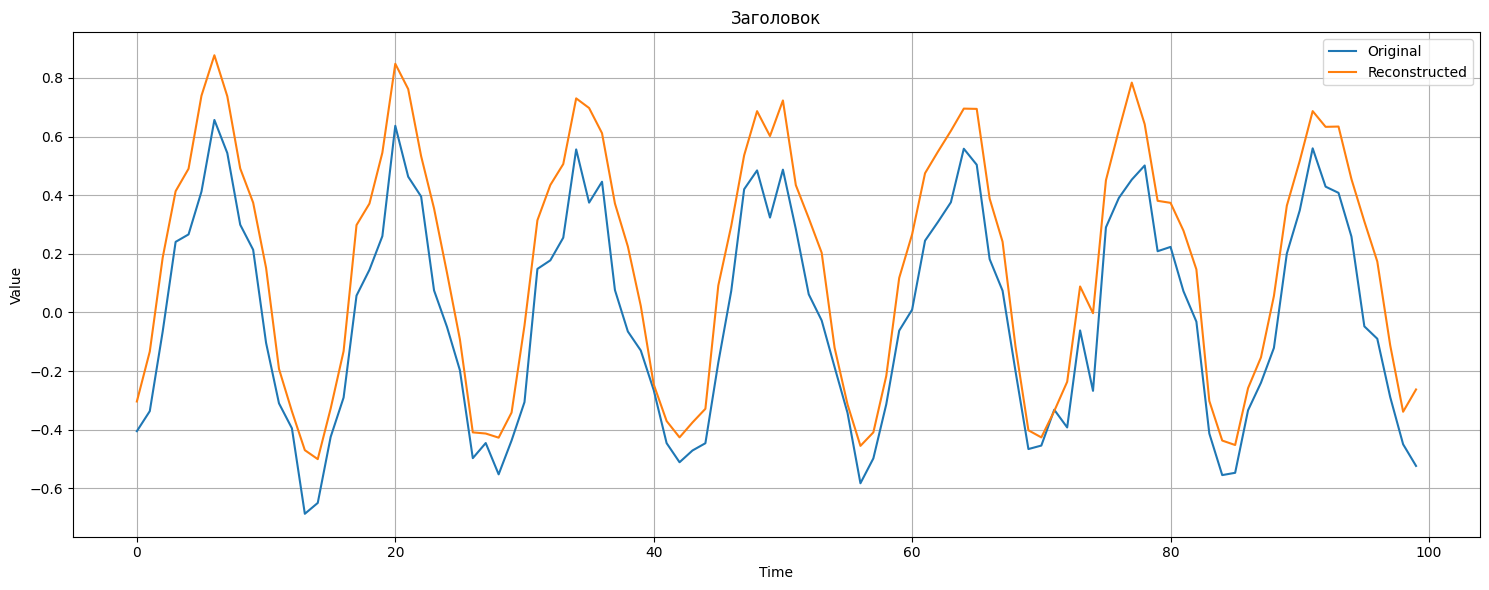

Model loaded from models/best_seasonal_base2_128.pth


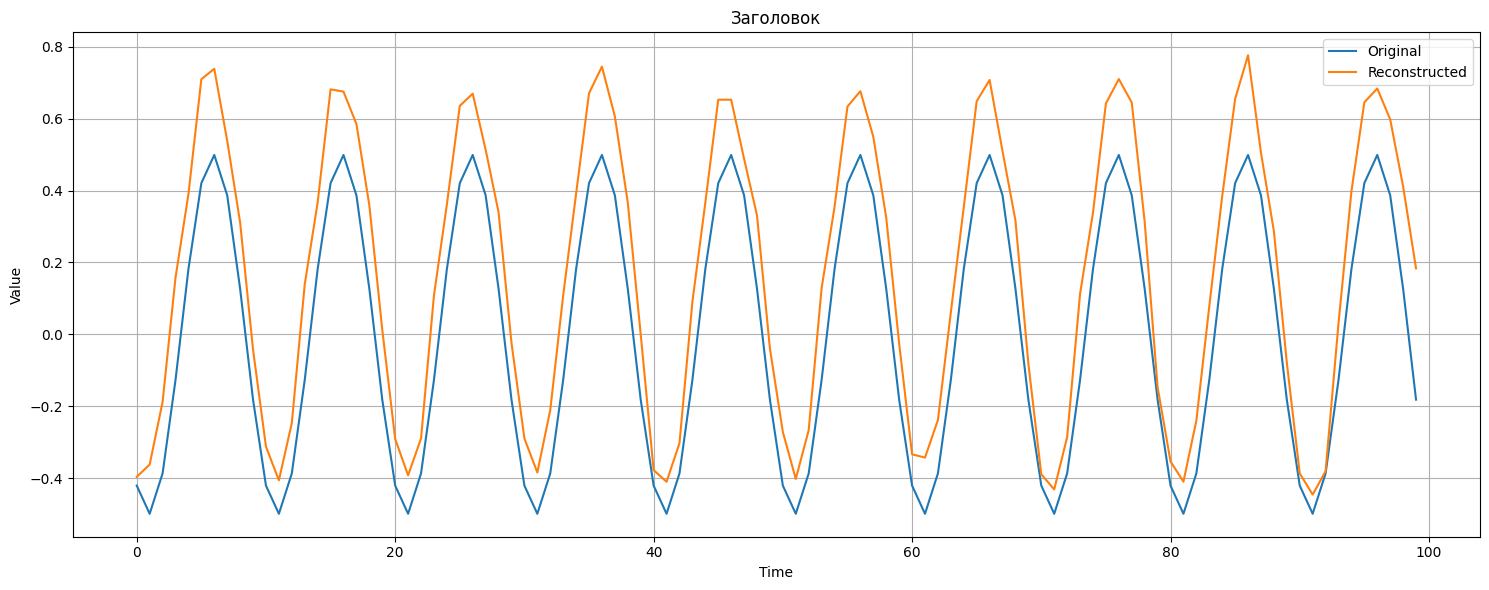

Model loaded from models/best_seasonal_base2_128.pth


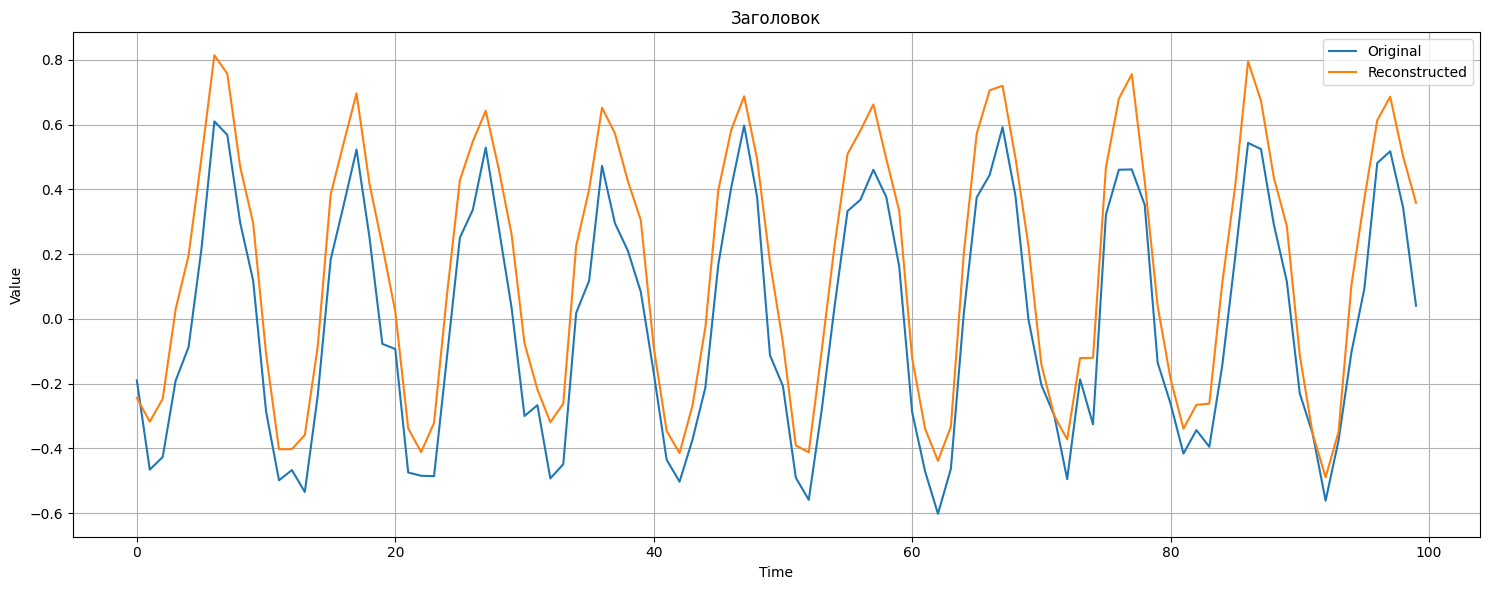

Model loaded from models/best_seasonal_base2_128.pth


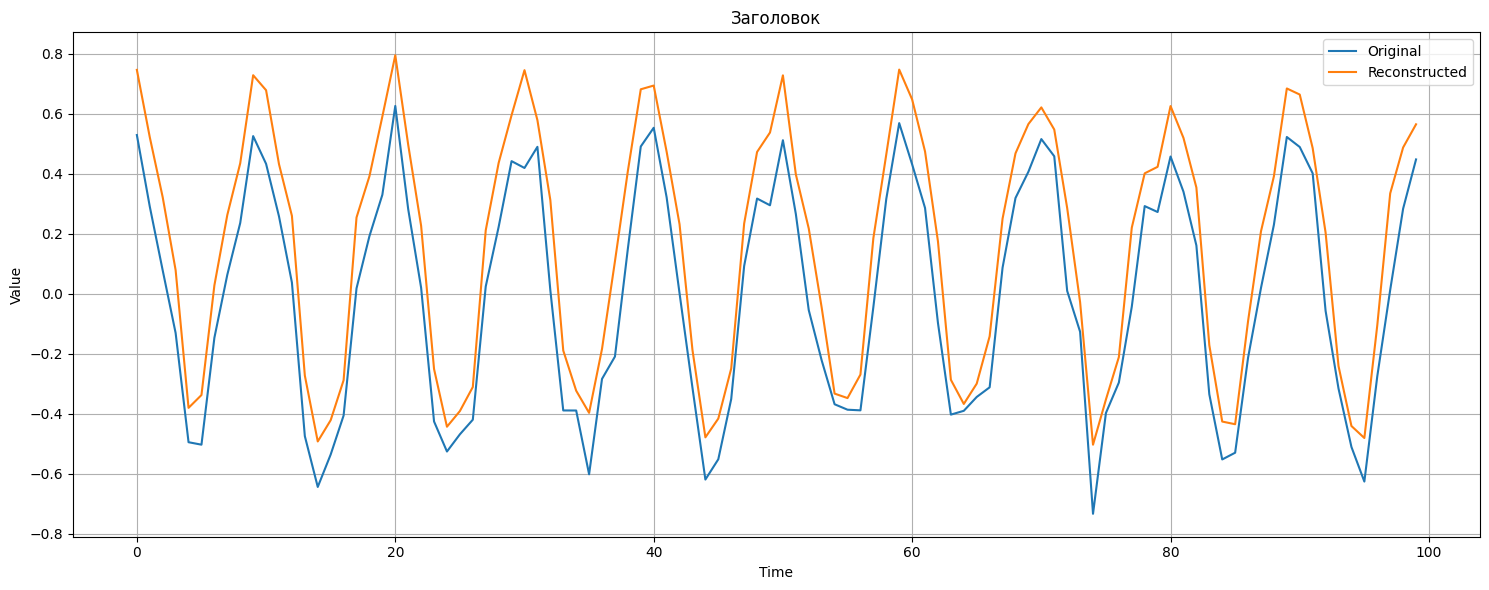

Model loaded from models/best_seasonal_base2_128.pth


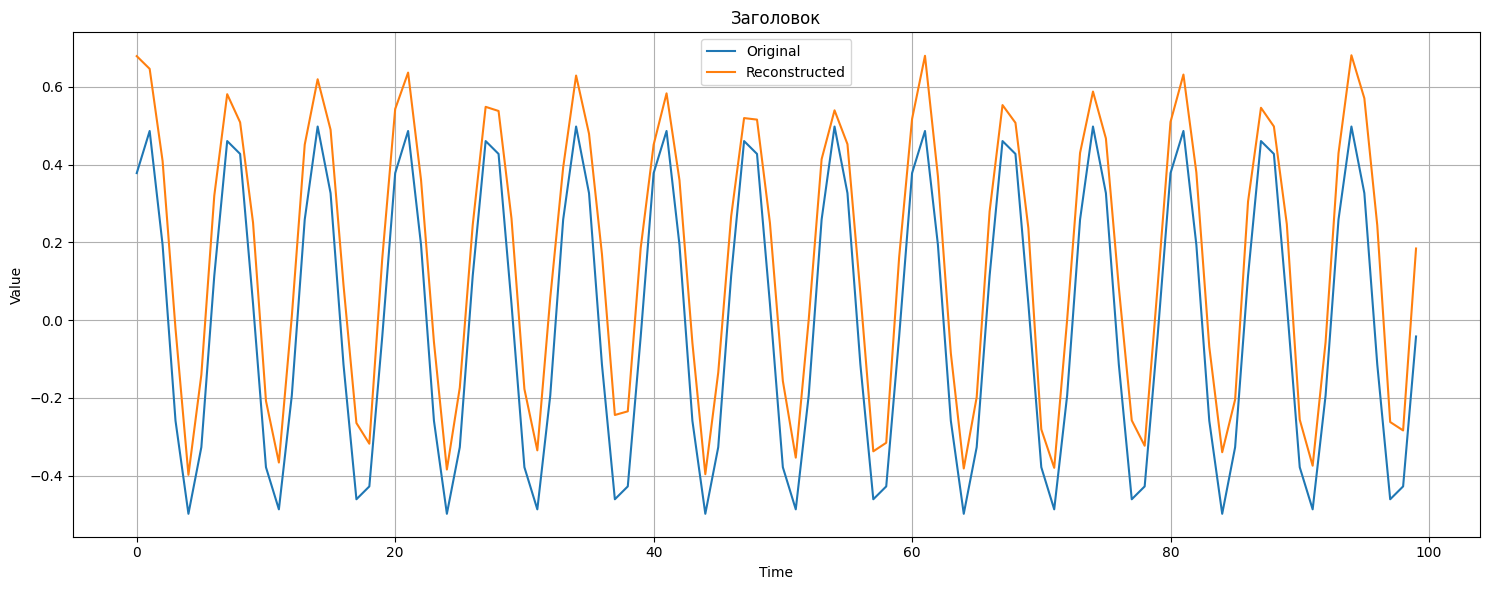

Model loaded from models/best_seasonal_base2_128.pth


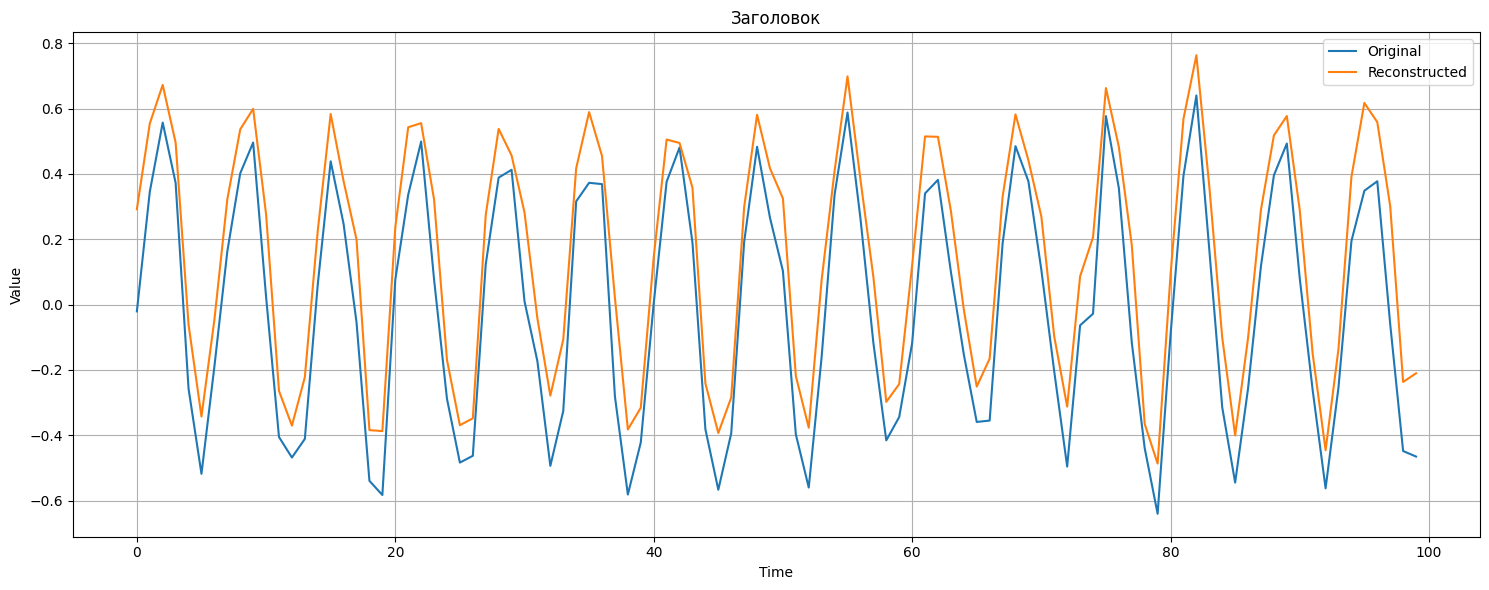

Model loaded from models/best_seasonal_base2_128.pth


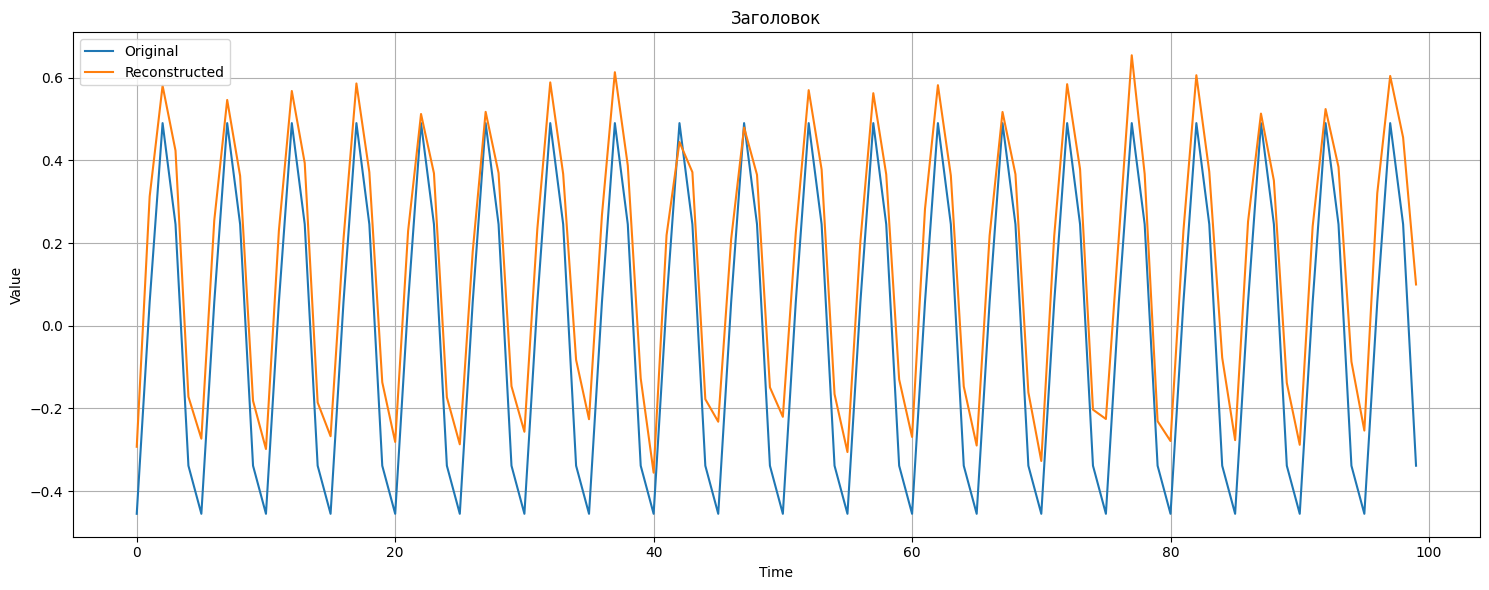

Model loaded from models/best_seasonal_base2_128.pth


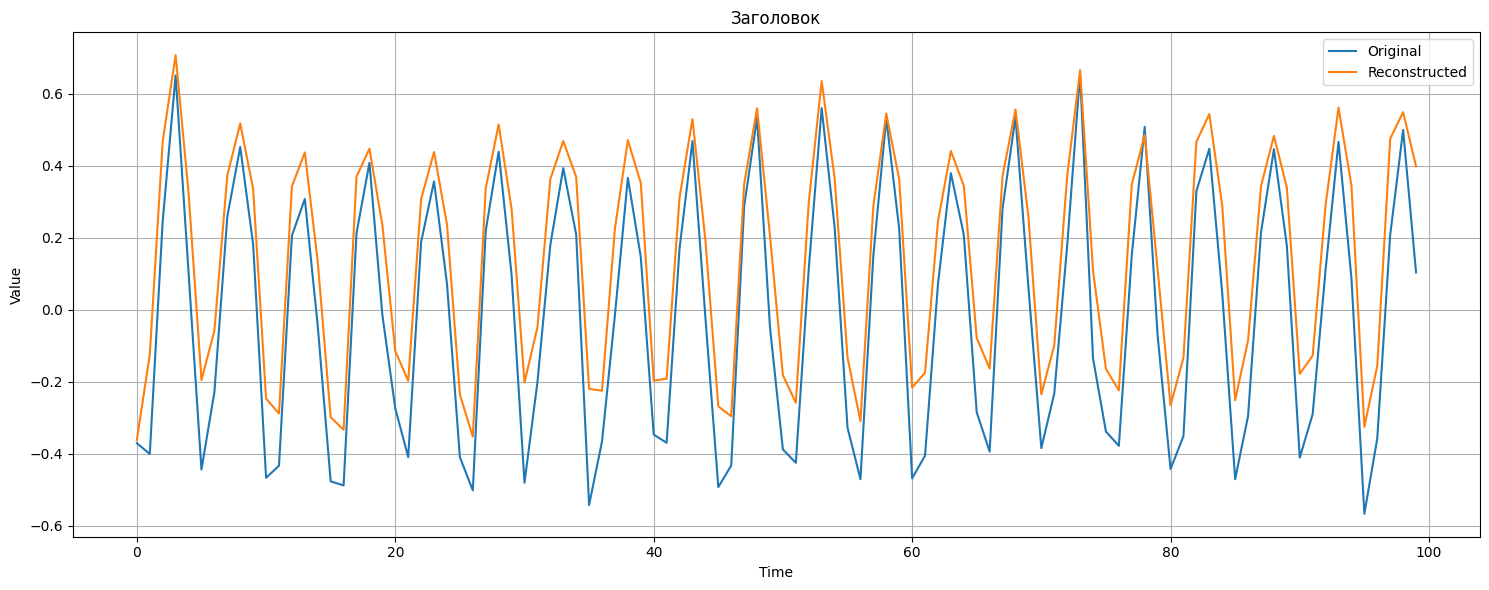

Model loaded from models/best_seasonal_base2_128.pth


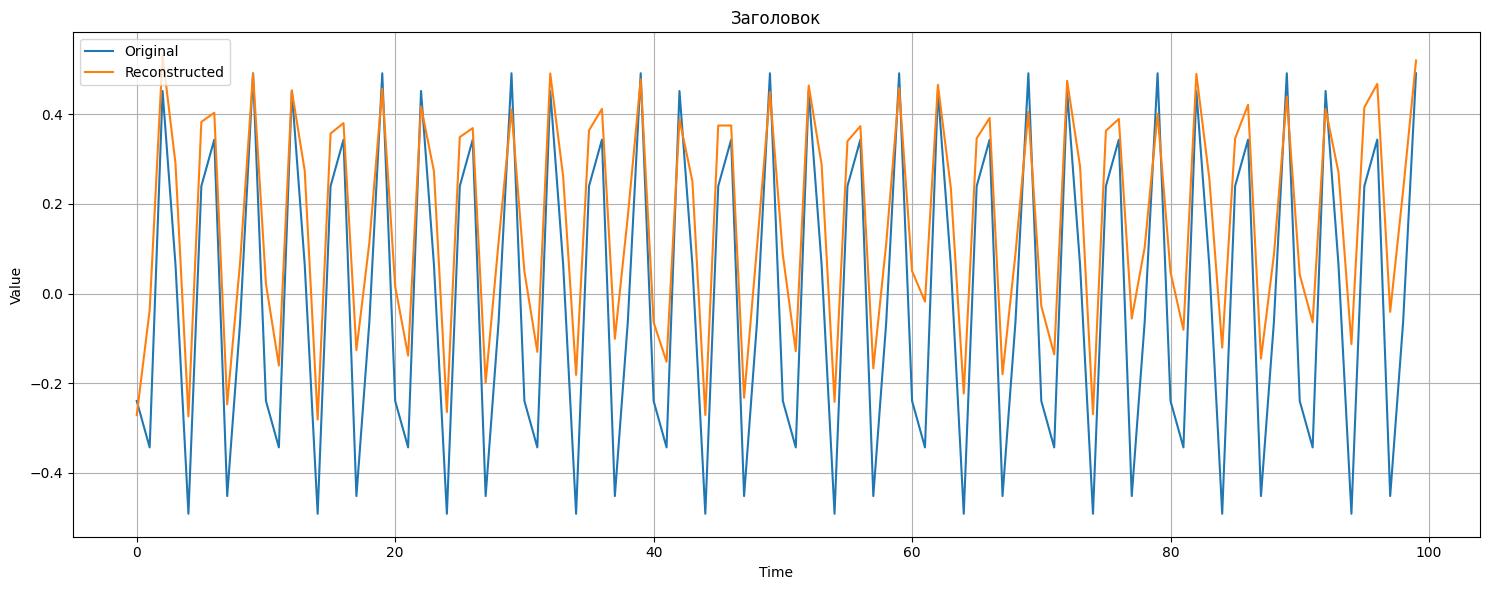

In [10]:
# Загрузка и подготовка данных
dataset = Parametric_dataset(
    data_path='data/seasonal_dataset2.json',
    normalize=False
)

for t in range(1,100, 5):
    
    trained_model = load_model(LSTM_Autoencoder, model_args, 'models/', 'best_seasonal_base2_128.pth').to(device) 
    
    # Тестирование на примере
    test_sample, _ = dataset[t]
    test_sample = test_sample.unsqueeze(0).unsqueeze(-1).to(device)  # [1, seq_len, 1]

    trained_model.eval()
    with torch.no_grad():
        reconstructed = trained_model(test_sample)

    test_sample = test_sample.cpu()
    reconstructed = reconstructed.cpu()

    # Визуализация
    plot_series(
        series_list=[
            test_sample.squeeze().numpy(),
            reconstructed.squeeze().numpy()
        ],
        labels=["Original", "Reconstructed"],
        ylabel="Value",
        xlabel="Time",
        figsize=(15, 6),
    )


In [ ]:


# Инициализация датасета
dataset = Synthetic_dataset(
    data_path='data/seasonal_synth.json',
    normalize=True,
    norm_type='minmax'
)

# Параметры модели
model_args = {
    'input_size': 1,
    'hidden_size': 128,
    'latent_size': 64,
    'num_layers': 2,
    'dropout': 0.3,
    'bidirectional': True
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка или обучение модели
model = load_trained_model(
    LSTM_Autoencoder,
    model_args,
    dataset,
    device,
    model_path="models/seasonal_ae.pth",
    batch_size=32,
    num_epochs=100,
    patience=15,
    save_every=10
)

# Тестирование модели
test_sample, _ = dataset[0]
test_sample = test_sample.unsqueeze(0).to(device)  # Добавляем batch dimension
if test_sample.dim() == 2:
    test_sample = test_sample.unsqueeze(-1)  # Добавляем feature dimension

model.eval()
with torch.no_grad():
    reconstructed = model(test_sample)

In [ ]:
from core.feature_extraction.basic_lstm_ae_synth import *

# Загрузка и подготовка данных
dataset = Synthetic_dataset(
    data_path='data/test_dataset1.json',
    normalize=False
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Инициализация модели 
model = LSTM_Autoencoder(
    seq_len=40,
    input_size=1,
    hidden_size=512,
    latent_size=128,
    num_layers=3,
    dropout=0.3,
    bidirectional=True
).to(device) 

# Обучение
trained_model = train_model(
    model=model,
    dataloader=dataloader,
    num_epochs=200,
    device=device 
)

# Тестирование на примере
test_sample, _ = dataset[0]
test_sample = test_sample.unsqueeze(0).unsqueeze(-1).to(device)  # [1, seq_len, 1]

trained_model.eval()
with torch.no_grad():
    reconstructed = trained_model(test_sample)

# Перенос на CPU для визуализации
test_sample = test_sample.cpu()
reconstructed = reconstructed.cpu()

# Визуализация
plot_series_grid(
    series_list=[
        test_sample.squeeze().numpy(),
        reconstructed.squeeze().numpy()
    ],
    labels=["Original", "Reconstructed"],
    plot_title="Autoencoder Results",
    ylabel="Value",
    xlabel="Time",
    figsize=(15, 6),
    layout='vertical'
)


In [ ]:
model